<a href="https://colab.research.google.com/github/jackhobday/nba-game-predictor/blob/main/nba_game_predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NBA Game Outcome Prediction
### CSCI 200 Machine Learning Final Project

**Git Repo:** https://github.com/jackhobday/nba-game-predictor

**What will be your goal in working on this project?**

*   My goal is to use previous results from NBA games, along with the season-long stats of each team at the time of the game, to predict the outcomes of future games.


**What will be your source for data for the project? If this requires you to gather data, how will you go about this?**


*   My data source is going to be https://www.basketball-reference.com/. I will create a Python script to scrape all the relevant tables and then upload the complete data set to my personal Git repo.


**What data cleaning, conversion, or preparation will you need to do to prepare your data set?**


* To create my dataset I will take game logs from every NBA team from 2015-2025. Once I have these I will merge the two game logs from each game into one row which will have game level data, as well as, advanced stats from the game for both teams. Using the stats from each game I can start to build season-level features which will have the teams advanced stats like offensive rating and efficiency up until the point of the game I will try to predict. Each row in the final, game-level data set will contain game outcome, home and away teams, season-to-date metrics for each teams, and any other features I decide to include.

**What kinds of exploratory data analysis will you do?**


*   I'll want to look at baseline home vs. away winning percentage, as well as, average performance metrics for teams at home versus away to try to quantify home field advantage. I'll also look at the distribution of the stat features using histograms and box plots.


**Which machine learning algorithms will you use to train models? Why are you choosing these algorithms?**


*   I will use **XGBoost** for both classification and regression approaches. XGBoost is well-suited for this problem because:
  - It handles complex datasets with lots of featyres like ours
  - It can capture non-linear relationships between features on its own
  - It uses built-in regularization to reduce overfitting
  - It offers feature importance scores to understand most important factors in predicting games
  
  I will train two models:
  1. **XGBoost Classifier**: Directly predicts win/loss (binary classification)
  2. **XGBoost Regressor**: Predicts point differential, then converts to win/loss predictions


**How will you attempt to optimize your models?**


*   I will optimize the models using several techniques:
  - **Cross-validation**: Rolling season splits (train on 2015-2020, test on 2021+)
  - **Sample weighting**: Apply exponential decay weighting to give more importance to recent seasons
  - **Early stopping**: Use validation set to prevent overfitting and find optimal number of boosting rounds
  - **Hyperparameter tuning**: XGBoost has many hyperparameters so I'll mainly focus on choosing standard values for the most important parameters that we discussed in class like max depth, number of estimators, and learning rate
  - **Feature engineering**: Create differential features (Team stat - Opponent stat) to capture matchup advantages. Most of this is done in the Git repo as opposed to in the notebook


**How will you analyze the accuracy of your models?**


*   I will evaluate model performance using the following metrics:
  - **Classification metrics**: Accuracy (percentage of correct predictions) and ROC-AUC (area under the receiver operating characteristic curve)
  - **Regression metrics** (for regressor): RMSE (Root Mean Squared Error), MAE (Mean Absolute Error), and R² (coefficient of determination)
  - **Cross-validation results**: Average performance across multiple test seasons (2020-21 through 2025-26)
  - **Feature importance analysis**: Identify which features contribute most to predictions
  - **Comparison**: Compare classifier vs. regressor approaches to determine which performs better




## **1. Data**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay

/var/folders/8g/f795lz5s741gv2l7gcmql8sh0000gn/T/ipykernel_89021/3198618922.py:1: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
# Load in dataset
pd.set_option('display.max_columns', None)
df = pd.read_csv('https://raw.githubusercontent.com/jackhobday/nba-game-predictor/main/data_merged/games_all_seasons.csv')
df.head(20)

,Season,Date,Team,Opponent,Is_Home,Game_Number_Team,Game_Number_Opp,Team_ORtg_avg,Team_DRtg_avg,Team_NetRtg_avg,Team_Pace_avg,Team_WinPct_avg,Team_eFG%_avg,Team_TOV%_avg,Team_ORB%_avg,Team_FT/FGA_avg,Team_TS%_avg,Team_TRB%_avg,Team_AST%_avg,Team_STL%_avg,Team_BLK%_avg,Team_NetRtg_last5,Team_NetRtg_last10,Team_WinPct_last5,Team_WinPct_last10,Team_Points_For_avg,Team_Points_Against_avg,Team_Current_Win_Streak,Team_Current_Loss_Streak,Team_Home_WinPct,Team_Away_WinPct,Team_Days_Rest,Team_Is_BackToBack,Opp_ORtg_avg,Opp_DRtg_avg,Opp_NetRtg_avg,Opp_Pace_avg,Opp_WinPct_avg,Opp_eFG%_avg,Opp_TOV%_avg,Opp_ORB%_avg,Opp_FT/FGA_avg,Opp_TS%_avg,Opp_TRB%_avg,Opp_AST%_avg,Opp_STL%_avg,Opp_BLK%_avg,Opp_NetRtg_last5,Opp_NetRtg_last10,Opp_WinPct_last5,Opp_WinPct_last10,Opp_Points_For_avg,Opp_Points_Against_avg,Opp_Current_Win_Streak,Opp_Current_Loss_Streak,Opp_Home_WinPct,Opp_Away_WinPct,Opp_Days_Rest,Opp_Is_BackToBack,Team_Score,Opp_Score,Result,OT,NetRtg_Diff,ORtg_Diff,DRtg_Diff,WinPct_Diff,NetRtg_Diff_last5,WinPct_Diff_last5,NetRtg_Diff_last10,WinPct_Diff_last10,eFG%_Diff,TOV%_Diff,ORB%_Diff,FT/FGA_Diff,Pace_Diff,Rest_Advantage,Win_Streak_Diff
0,2015-16,2015-10-27,ATL,DET,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0.0,0,1,94,106,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,2015-16,2015-10-27,CHI,CLE,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0.0,0,1,97,95,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2,2015-16,2015-10-27,GSW,NOP,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0.0,0,1,111,95,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
3,2015-16,2015-10-28,BKN,CHI,1,1,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,97.0,95.0,2.0,100.0,1.0,0.47,11.8,15.2,0.18,0.50,48.5,35.1,6.0,15.4,2.0,2.0,1.0,1.0,97.0,95.0,1,0,NaN,0.0,1,0,100,115,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,-1
4,2015-16,2015-10-28,BOS,PHI,1,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0.0,0,1,112,95,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
5,2015-16,2015-10-28,CHA,MIA,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0.0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,94,104,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
6,2015-16,2015-10-28,CLE,MEM,0,2,1,95.0,97.0,-2.0,100.0,0.0,0.45,9.8,21.6,0.11,0.47,51.5,68.4,5.0,10.3,-2.0,-2.0,0.0,0.0,95.0,97.0,0,1,NaN,0.0,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,106,76,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0
7,2015-16,2015-10-28,DAL,PHX,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0.0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,111,95,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
8,2015-16,2015-10-28,DEN,HOU,0,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,NaN,0.0,0,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,NaN,0,1,105,85,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
9,2015-16,2015-10-28,DET,UTA,1,2,1,111.2,98.6,12.6,95.3,1.0,0.45,12.3,41.1,0.21,0.49,59.6,62.2,5.2,5.5,12.6,12.6,1.0,1.0,106.0,94.0,1,0,0.0,NaN,1,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [3]:
print(df.columns)

Index(['Season', 'Date', 'Team', 'Opponent', 'Is_Home', 'Game_Number_Team',
       'Game_Number_Opp', 'Team_ORtg_avg', 'Team_DRtg_avg', 'Team_NetRtg_avg',
       'Team_Pace_avg', 'Team_WinPct_avg', 'Team_eFG%_avg', 'Team_TOV%_avg',
       'Team_ORB%_avg', 'Team_FT/FGA_avg', 'Team_TS%_avg', 'Team_TRB%_avg',
       'Team_AST%_avg', 'Team_STL%_avg', 'Team_BLK%_avg', 'Team_NetRtg_last5',
       'Team_NetRtg_last10', 'Team_WinPct_last5', 'Team_WinPct_last10',
       'Team_Points_For_avg', 'Team_Points_Against_avg',
       'Team_Current_Win_Streak', 'Team_Current_Loss_Streak',
       'Team_Home_WinPct', 'Team_Away_WinPct', 'Team_Days_Rest',
       'Team_Is_BackToBack', 'Opp_ORtg_avg', 'Opp_DRtg_avg', 'Opp_NetRtg_avg',
       'Opp_Pace_avg', 'Opp_WinPct_avg', 'Opp_eFG%_avg', 'Opp_TOV%_avg',
       'Opp_ORB%_avg', 'Opp_FT/FGA_avg', 'Opp_TS%_avg', 'Opp_TRB%_avg',
       'Opp_AST%_avg', 'Opp_STL%_avg', 'Opp_BLK%_avg', 'Opp_NetRtg_last5',
       'Opp_NetRtg_last10', 'Opp_WinPct_last5', 'Opp_WinPc

## **2. EDA**

In [4]:
# Basic statistical measures
df.describe()

,Is_Home,Game_Number_Team,Game_Number_Opp,Team_ORtg_avg,Team_DRtg_avg,Team_NetRtg_avg,Team_Pace_avg,Team_WinPct_avg,Team_eFG%_avg,Team_TOV%_avg,Team_ORB%_avg,Team_FT/FGA_avg,Team_TS%_avg,Team_TRB%_avg,Team_AST%_avg,Team_STL%_avg,Team_BLK%_avg,Team_NetRtg_last5,Team_NetRtg_last10,Team_WinPct_last5,Team_WinPct_last10,Team_Points_For_avg,Team_Points_Against_avg,Team_Current_Win_Streak,Team_Current_Loss_Streak,Team_Home_WinPct,Team_Away_WinPct,Team_Days_Rest,Team_Is_BackToBack,Opp_ORtg_avg,Opp_DRtg_avg,Opp_NetRtg_avg,Opp_Pace_avg,Opp_WinPct_avg,Opp_eFG%_avg,Opp_TOV%_avg,Opp_ORB%_avg,Opp_FT/FGA_avg,Opp_TS%_avg,Opp_TRB%_avg,Opp_AST%_avg,Opp_STL%_avg,Opp_BLK%_avg,Opp_NetRtg_last5,Opp_NetRtg_last10,Opp_WinPct_last5,Opp_WinPct_last10,Opp_Points_For_avg,Opp_Points_Against_avg,Opp_Current_Win_Streak,Opp_Current_Loss_Streak,Opp_Home_WinPct,Opp_Away_WinPct,Opp_Days_Rest,Opp_Is_BackToBack,Team_Score,Opp_Score,Result,OT,NetRtg_Diff,ORtg_Diff,DRtg_Diff,WinPct_Diff,NetRtg_Diff_last5,WinPct_Diff_last5,NetRtg_Diff_last10,WinPct_Diff_last10,eFG%_Diff,TOV%_Diff,ORB%_Diff,FT/FGA_Diff,Pace_Diff,Rest_Advantage,Win_Streak_Diff
count,12596.000000,12596.000000,12596.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12596.000000,12596.000000,6299.000000,6297.000000,12596.000000,12596.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12431.000000,12596.000000,12596.000000,6297.000000,6299.000000,12596.000000,12596.000000,12596.000000,12596.000000,12596.000000,12596.000000,12420.000000,12420.000000,12420.000000,12420.000000,12420.000000,12420.000000,12420.000000,12420.000000,12420.000000,12420.000000,12420.000000,12420.000000,12420.000000,12596.000000,12596.000000
mean,0.500079,39.624008,39.572960,110.665294,110.423315,0.241997,98.834530,0.506667,0.527755,12.913156,23.308220,0.202985,0.563601,49.986827,60.214083,7.796945,8.917108,0.162584,0.183737,0.504772,0.505004,110.067685,109.822398,1.156875,1.119324,0.559883,0.424655,2.210543,0.013099,110.370832,110.569725,-0.198882,98.804396,0.494616,0.525849,12.957311,23.413749,0.204119,0.562055,50.021703,59.505562,7.845903,9.096828,-0.143082,-0.155531,0.495743,0.495760,109.731294,109.933536,1.129724,1.230629,0.546306,0.415887,2.211893,0.013099,110.731661,110.360908,0.510003,0.054859,0.440713,0.294836,-0.145871,0.012223,0.305381,0.009198,0.339014,0.009414,0.001922,-0.044009,-0.110309,-0.001089,0.029581,-0.001350,0.027151
std,0.500020,23.213385,23.203664,5.344005,4.818599,5.666210,2.679252,0.181183,0.028511,1.237323,3.022617,0.027056,0.026751,1.913220,4.618118,1.080111,1.727328,8.061206,6.804553,0.261333,0.217569,6.488626,6.149689,1.816951,1.857052,0.230611,0.215407,4.297193,0.113705,5.055344,5.098654,5.861094,2.826029,0.182842,0.026240,1.232556,3.129347,0.028301,0.024928,1.993208,4.923923,1.078158,1.688750,8.215830,7.043727,0.265758,0.222592,6.384670,6.712542,1.838541,2.062598,0.235688,0.214057,4.291183,0.113705,13.225773,12.781789,0.499920,0.227713,8.166890,5.647542,5.255281,0.258826,11.662199,0.378820,9.855686,0.314637,0.032242,1.655842,4.143110,0.036219,3.176274,2.074228,2.601656
min,0.000000,1.000000,1.000000,84.600000,83.000000,-32.900000,89.600000,0.000000,0.390000,3.900000,9.300000,0.060000,0.420000,35.200000,32.400000,1.800000,0.000000,-32.900000,-32.900000,0.000000,0.000000,85.000000,83.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,76.200000,76.200000,-48.200000,89.600000,0.000000,0.340000,5.700000,5.900000,0.030000,0.390000,32.900000,34.700000,2.200000,0.000000,-48.200000,-48.200000,0.000000,0.000000,76.000000,76.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,64.00

### Summary Statistics Interpretation

The summary statistics above reveal several key insights about our dataset of 12,596 NBA games from the 2015-16 through 2025-26 seasons (11 seasons total):

**Target Variable (Result)**
- The mean of 0.510 indicates nearly perfect class balance: teams in the "Team" column win about 51% of games. This is expected since the dataset is evenly split between home and away games, and home teams win slightly more often.

**Home Court Advantage**
- `Is_Home` has a mean of 0.50, confirming perfectly balanced home/away representation.
- `Team_Home_WinPct` averages 0.560 (56.0%) while `Team_Away_WinPct` averages 0.425 (42.5%), quantifying the significant home court advantage in the NBA.

**Rating Differentials (Key Predictive Features)**
- `NetRtg_Diff` (team's net rating minus opponent's) has a mean of 0.44, with a standard deviation of ~8.2 points. This differential captures the overall quality gap between teams.
- The range spans from -42.6 to +44.7, showing the wide variation in matchup quality from historically bad teams facing elite teams.

**Missing Data**
- Some features like `Team_Home_WinPct` and `Team_Away_WinPct` have fewer observations (~6,300 each) because they only apply to home and away games respectively.
- Season-average features have ~12,431 observations (out of 12,596) because early-season games lack historical data to compute rolling averages.

### Feature Engineering Overview

The dataset contains engineered features that capture team performance, recent form, and matchup dynamics. Features are calculated **before** each game to prevent data leakage. The features fall into several categories:

#### 1. **Team Season-to-Date Statistics** (Cumulative averages)
- **Offensive/Defensive Ratings**: `Team_ORtg_avg`, `Team_DRtg_avg`, `Team_NetRtg_avg`
- **Advanced Metrics**: `Team_eFG%_avg`, `Team_TS%_avg`, `Team_TOV%_avg`, `Team_ORB%_avg`, `Team_FT/FGA_avg`
- **Other Stats**: `Team_Pace_avg`, `Team_TRB%_avg`, `Team_AST%_avg`, `Team_STL%_avg`, `Team_BLK%_avg`
- **Win Percentage**: `Team_WinPct_avg`

#### 2. **Team Recent Form** (Last N games)
- **Last 5 games**: `Team_NetRtg_last5`, `Team_WinPct_last5`
- **Last 10 games**: `Team_NetRtg_last10`, `Team_WinPct_last10`

#### 3. **Team Contextual Features**
- **Streaks**: `Team_Current_Win_Streak`, `Team_Current_Loss_Streak`
- **Home/Away Splits**: `Team_Home_WinPct`, `Team_Away_WinPct`
- **Rest**: `Team_Days_Rest`, `Team_Is_BackToBack`
- **Game Number**: `Game_Number_Team` (position in season)

#### 4. **Opponent Features** (Same categories as Team)
- All opponent features mirror the team features (e.g., `Opp_ORtg_avg`, `Opp_NetRtg_last5`, etc.)

#### 5. **Differential Features** (Team - Opponent)
- **Rating Differentials**: `NetRtg_Diff`, `ORtg_Diff`, `DRtg_Diff`
- **Win Percentage Differential**: `WinPct_Diff`
- **Recent Form Differentials**: `NetRtg_Diff_last5`, `NetRtg_Diff_last10`, `WinPct_Diff_last5`, `WinPct_Diff_last10`
- **Advanced Stat Differentials**: `eFG%_Diff`, `TOV%_Diff`, `ORB%_Diff`, `FT/FGA_Diff`, `Pace_Diff`
- **Context Differentials**: `Rest_Advantage`, `Win_Streak_Diff`

#### 6. **Game Context**
- **Home Advantage**: `Is_Home` (1 if home, 0 if away)

These features are designed to capture:
- **Team strength** (season averages)
- **Recent momentum** (last 5/10 games)
- **Matchup advantages** (differentials)
- **Situational factors** (rest, home/away, streaks)


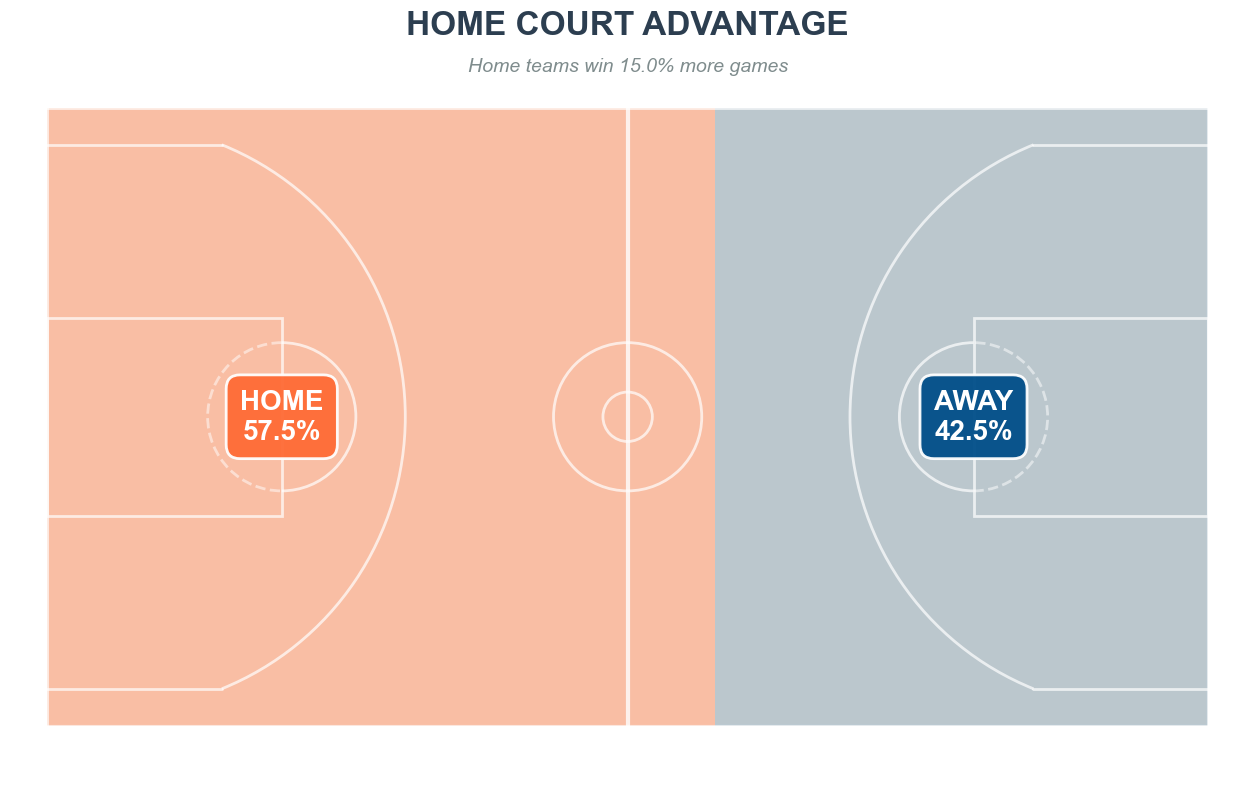


HOME vs AWAY STATISTICS
Home Team Win Rate: 0.575
Away Team Win Rate: 0.445
Home Court Advantage: 0.130


In [5]:
# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 6)

# Home vs Away Analysis
home_away_stats = df.groupby('Is_Home')['Result'].agg(['count', 'sum', 'mean']).reset_index()
home_away_stats.columns = ['Is_Home', 'Total_Games', 'Wins', 'Win_Rate']
home_away_stats['Location'] = home_away_stats['Is_Home'].map({1: 'Home', 0: 'Away'})

# Create basketball court visualization
from matplotlib.patches import Rectangle, Arc, Circle
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 8))

# Get win rates
# Note: Every NBA game has exactly one winner (home or away)
# So away_rate should be 1 - home_rate to ensure they add up to 100%
home_rate = home_away_stats[home_away_stats['Is_Home']==1]['Win_Rate'].values[0]
away_rate = 1 - home_rate

# Court dimensions (NBA regulation)
court_length = 94  # Full court length in feet
court_width = 50   # Court width in feet
half_court = court_length / 2

# Court background with subtle wood texture color
ax.add_patch(Rectangle((0, 0), court_length, court_width, 
                       facecolor='#D4A574', edgecolor='white', linewidth=3, alpha=0.2))

# Half court line (dividing home/away)
ax.plot([half_court, half_court], [0, court_width], 
        color='white', linewidth=3, linestyle='-', alpha=0.8)

# Home side (left) - extend by home_rate percentage to visualize advantage
# If home wins 57.5%, orange extends 7.5% (57.5-50) past half court
home_extension = (home_rate - 0.5) * court_length  # Convert percentage to court distance
home_alpha = 0.3 + (home_rate - 0.5) * 0.8  # Scale appropriately
ax.add_patch(Rectangle((0, 0), half_court + home_extension, court_width, 
                       facecolor='#FF6B35', alpha=home_alpha, edgecolor='none'))

# Away side (right) - fill remaining area
away_alpha = 0.3 + (away_rate - 0.5) * 0.8
ax.add_patch(Rectangle((half_court + home_extension, 0), half_court - home_extension, court_width, 
                       facecolor='#004E89', alpha=away_alpha, edgecolor='none'))

# Baseline lines
ax.plot([0, 0], [0, court_width], color='white', linewidth=2, alpha=0.7)
ax.plot([court_length, court_length], [0, court_width], color='white', linewidth=2, alpha=0.7)
ax.plot([0, court_length], [0, 0], color='white', linewidth=2, alpha=0.7)
ax.plot([0, court_length], [court_width, court_width], color='white', linewidth=2, alpha=0.7)

# HOME SIDE (left)
# Hoop position
hoop_distance = 5.25  # Distance from baseline to hoop center
# Three-point arc - centered at hoop, curving towards mid-court
three_pt_radius = 23.75
# Arc should go from bottom-right to top-right of basket (angles -68° to +68°)
three_pt_arc_home = Arc((hoop_distance, court_width/2), three_pt_radius*2, three_pt_radius*2,
                        theta1=-68, theta2=68, 
                        color='white', linewidth=2, fill=False, alpha=0.7)
ax.add_patch(three_pt_arc_home)

# Three-point line corners (straight lines from baseline to where arc begins)
three_pt_corner_distance = 3  # Distance from sideline in corners
# Calculate where arc meets the corner line
corner_x = hoop_distance + np.sqrt(three_pt_radius**2 - (court_width/2 - three_pt_corner_distance)**2)
ax.plot([0, corner_x], [three_pt_corner_distance, three_pt_corner_distance], 
        color='white', linewidth=2, alpha=0.7)
ax.plot([0, corner_x], [court_width - three_pt_corner_distance, court_width - three_pt_corner_distance], 
        color='white', linewidth=2, alpha=0.7)

# Paint/key (home side)
paint_width = 16
ax.add_patch(Rectangle((0, court_width/2 - paint_width/2), 19, paint_width, 
                       facecolor='none', edgecolor='white', linewidth=2, alpha=0.7))

# Free throw circle (home side) - solid semicircle on right (closer to 3-pt line)
ft_line_distance = 19  # Distance from baseline to free throw line
ft_circle_home = Arc((ft_line_distance, court_width/2), 12, 12, 
                     theta1=-90, theta2=90, color='white', linewidth=2, alpha=0.7)
ax.add_patch(ft_circle_home)
# Dashed semicircle on left (in the lane)
ft_circle_home_dash = Arc((ft_line_distance, court_width/2), 12, 12, 
                          theta1=90, theta2=270, color='white', linewidth=2, 
                          alpha=0.5, linestyle='--')
ax.add_patch(ft_circle_home_dash)

# AWAY SIDE (right) - mirror of home side
# Three-point arc - centered at hoop, curving towards mid-court
# Arc should go from bottom-left to top-left of basket (angles 112° to 248°)
three_pt_arc_away = Arc((court_length - hoop_distance, court_width/2), three_pt_radius*2, three_pt_radius*2,
                        theta1=112, theta2=248, 
                        color='white', linewidth=2, fill=False, alpha=0.7)
ax.add_patch(three_pt_arc_away)

# Three-point line corners (away side)
corner_x_away = court_length - corner_x
ax.plot([court_length, corner_x_away], [three_pt_corner_distance, three_pt_corner_distance], 
        color='white', linewidth=2, alpha=0.7)
ax.plot([court_length, corner_x_away], [court_width - three_pt_corner_distance, court_width - three_pt_corner_distance], 
        color='white', linewidth=2, alpha=0.7)

# Paint/key (away side)
ax.add_patch(Rectangle((court_length - 19, court_width/2 - paint_width/2), 19, paint_width, 
                       facecolor='none', edgecolor='white', linewidth=2, alpha=0.7))

# Free throw circle (away side) - solid semicircle on left (closer to 3-pt line)
ft_circle_away = Arc((court_length - ft_line_distance, court_width/2), 12, 12, 
                     theta1=90, theta2=270, color='white', linewidth=2, alpha=0.7)
ax.add_patch(ft_circle_away)
# Dashed semicircle on right (in the lane)
ft_circle_away_dash = Arc((court_length - ft_line_distance, court_width/2), 12, 12, 
                          theta1=-90, theta2=90, color='white', linewidth=2, 
                          alpha=0.5, linestyle='--')
ax.add_patch(ft_circle_away_dash)

# Center circle
center_circle_outer = Circle((half_court, court_width/2), 6, 
                             color='white', fill=False, linewidth=2, alpha=0.7)
ax.add_patch(center_circle_outer)
center_circle_inner = Circle((half_court, court_width/2), 2, 
                             color='white', fill=False, linewidth=2, alpha=0.7)
ax.add_patch(center_circle_inner)

# Add text labels with win percentages - positioned in free throw circles
# HOME side - in free throw circle
ax.text(ft_line_distance, court_width/2, f'HOME\n{home_rate:.1%}', 
        ha='center', va='center', fontsize=20, fontweight='bold', 
        color='white', zorder=5,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FF6B35', 
                 edgecolor='white', linewidth=2, alpha=0.95))

# AWAY side - in free throw circle
ax.text(court_length - ft_line_distance, court_width/2, f'AWAY\n{away_rate:.1%}', 
        ha='center', va='center', fontsize=20, fontweight='bold', 
        color='white', zorder=5,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#004E89', 
                 edgecolor='white', linewidth=2, alpha=0.95))

# Title
ax.text(half_court, court_width + 6, 'HOME COURT ADVANTAGE', 
        ha='center', fontsize=24, fontweight='bold', color='#2C3E50')

# Subtitle
advantage = home_rate - away_rate
ax.text(half_court, court_width + 3, 
        f'Home teams win {advantage:.1%} more games', 
        ha='center', fontsize=14, color='#7F8C8D', style='italic')

# Remove axes
ax.set_xlim(-3, court_length+3)
ax.set_ylim(-4, court_width+8)
ax.set_aspect('equal')
ax.axis('off')

plt.tight_layout()
plt.show()

# Print statistics
print("\n" + "="*50)
print("HOME vs AWAY STATISTICS")
print("="*50)
print(f"Home Team Win Rate: {home_away_stats[home_away_stats['Is_Home']==1]['Win_Rate'].values[0]:.3f}")
print(f"Away Team Win Rate: {home_away_stats[home_away_stats['Is_Home']==0]['Win_Rate'].values[0]:.3f}")
print(f"Home Court Advantage: {home_away_stats[home_away_stats['Is_Home']==1]['Win_Rate'].values[0] - home_away_stats[home_away_stats['Is_Home']==0]['Win_Rate'].values[0]:.3f}")
print("="*50)

### Home Court Advantage: A Baseline Model

The home vs. away win rate analysis above establishes a benchmark for our models. With **home teams winning approximately 57.5%** of games across our dataset, we have a natural **baseline (null) model**: simply predicting the home team wins every game would achieve ~57.5% accuracy.

**Why does home court advantage exist?**
- Crowd support and familiar environment
- No travel fatigue for home team

**Implications for our models:**
- Any model we build must exceed 57.5% accuracy to be considered useful
- The ~13 percentage point gap between home (57.5%) and away (44.5%) win rates confirms that `Is_Home` should be a valuable feature in our models

/var/folders/8g/f795lz5s741gv2l7gcmql8sh0000gn/T/ipykernel_89021/1065585322.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  netrtg_analysis = df_clean.groupby('NetRtg_Diff_Bin')['Result'].agg(['count', 'sum', 'mean']).reset_index()


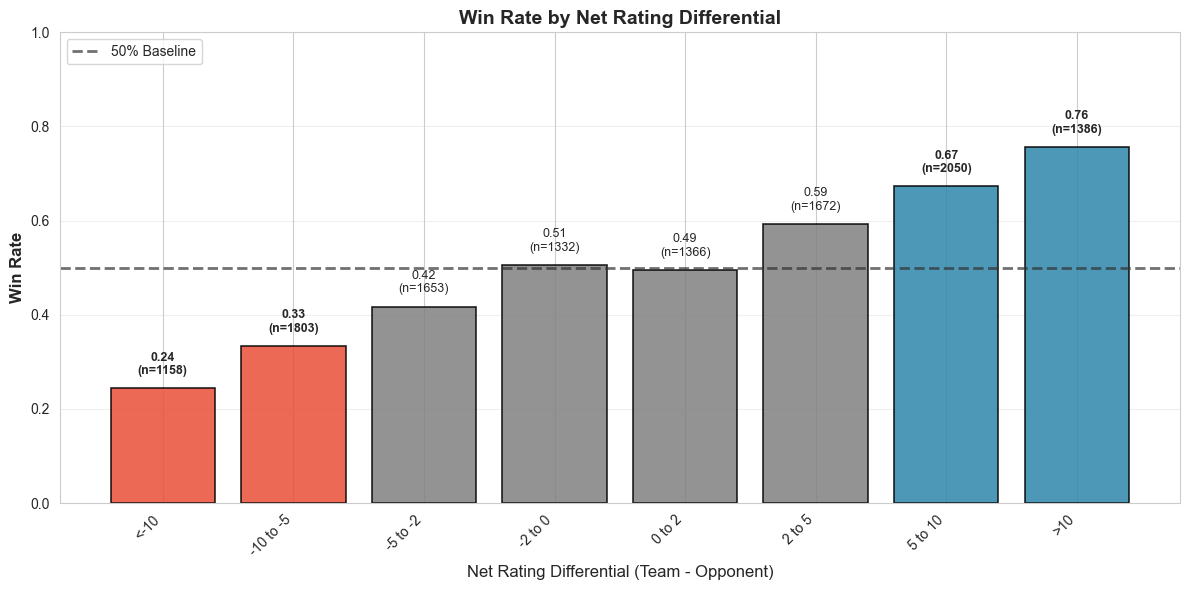


NET RATING DIFFERENTIAL ANALYSIS
Mean NetRtg_Diff for Wins: 2.84
Mean NetRtg_Diff for Losses: -2.07
Correlation (NetRtg_Diff vs Result): 0.300


In [6]:
# Filter out NaN values for NetRtg_Diff
df_clean = df.dropna(subset=['NetRtg_Diff', 'Result']).copy()

# Create bins for NetRtg_Diff
df_clean['NetRtg_Diff_Bin'] = pd.cut(df_clean['NetRtg_Diff'],
                                     bins=[-np.inf, -10, -5, -2, 0, 2, 5, 10, np.inf],
                                     labels=['<-10', '-10 to -5', '-5 to -2', '-2 to 0',
                                            '0 to 2', '2 to 5', '5 to 10', '>10'])

# Calculate win rate by bin
netrtg_analysis = df_clean.groupby('NetRtg_Diff_Bin')['Result'].agg(['count', 'sum', 'mean']).reset_index()
netrtg_analysis.columns = ['NetRtg_Diff_Bin', 'Total_Games', 'Wins', 'Win_Rate']

# Create visualization with consistent greyscale theme + highlights
fig, ax = plt.subplots(figsize=(12, 6))

# Define colors: highlight extreme bins (strong favorites/underdogs)
HIGHLIGHT_COLOR = '#2E86AB'  # Blue for high win rates
HIGHLIGHT_RED = '#E94F37'    # Red for low win rates
GREY_COLOR = '#808080'       # Grey for middle bins
n_bins = len(netrtg_analysis)
colors = []
for i, rate in enumerate(netrtg_analysis['Win_Rate']):
    if i >= n_bins - 2:  # Top 2 bins (favorites)
        colors.append(HIGHLIGHT_COLOR)
    elif i < 2:  # Bottom 2 bins (underdogs)
        colors.append(HIGHLIGHT_RED)
    else:
        colors.append(GREY_COLOR)

bars = ax.bar(range(len(netrtg_analysis)), netrtg_analysis['Win_Rate'],
              color=colors, alpha=0.85, edgecolor='black', linewidth=1.2)
ax.set_xticks(range(len(netrtg_analysis)))
ax.set_xticklabels(netrtg_analysis['NetRtg_Diff_Bin'], rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Win Rate', fontsize=12, fontweight='bold')
ax.set_xlabel('Net Rating Differential (Team - Opponent)', fontsize=12)
ax.set_title('Win Rate by Net Rating Differential', fontsize=14, fontweight='bold')
ax.axhline(y=0.5, color='#333333', linestyle='--', linewidth=2, alpha=0.7, label='50% Baseline')
ax.set_ylim([0, 1])
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='upper left')

for i, (rate, count) in enumerate(zip(netrtg_analysis['Win_Rate'], netrtg_analysis['Total_Games'])):
    color = '#333333'
    if i >= n_bins - 2 or i < 2:
        color = colors[i]
    ax.text(i, rate + 0.03, f'{rate:.2f}\n(n={count})', ha='center', fontsize=9, fontweight='bold' if i >= n_bins - 2 or i < 2 else 'normal')

plt.tight_layout()
plt.show()

# Print key statistics
print("\n" + "="*50)
print("NET RATING DIFFERENTIAL ANALYSIS")
print("="*50)
print(f"Mean NetRtg_Diff for Wins: {df_clean[df_clean['Result']==1]['NetRtg_Diff'].mean():.2f}")
print(f"Mean NetRtg_Diff for Losses: {df_clean[df_clean['Result']==0]['NetRtg_Diff'].mean():.2f}")
print(f"Correlation (NetRtg_Diff vs Result): {df_clean['NetRtg_Diff'].corr(df_clean['Result']):.3f}")
print("="*50)

### Net Rating Differential Analysis

The Net Rating Differential (`NetRtg_Diff`) chart above demonstrates the strongest predictor of game outcomes in our dataset:

**Key Observations:**
- When a team has a **significantly better net rating** (far right of chart), they win 75-80%+ of their games
- When teams have **similar net ratings** (middle bins), win rates hover around 50-55%
- Teams with **much worse net ratings** (far left) rarely win

**What this tells us:**
1. **NetRtg_Diff is likely our most important feature** - It captures the overall quality difference between teams entering a game
2. **Upsets happen** - Even the worst matchups (leftmost bins) still show ~20-30% win rates. This is expected as the NBA is known for upsets as one player can take over a game

**Model Implications:**
This visualization suggests that differential features (Team stat - Opponent stat) may be more predictive than raw team statistics alone, as they directly capture the matchup advantage

## **3. Feature Preparation**

In [7]:
df.columns.tolist()

['Season',
 'Date',
 'Team',
 'Opponent',
 'Is_Home',
 'Game_Number_Team',
 'Game_Number_Opp',
 'Team_ORtg_avg',
 'Team_DRtg_avg',
 'Team_NetRtg_avg',
 'Team_Pace_avg',
 'Team_WinPct_avg',
 'Team_eFG%_avg',
 'Team_TOV%_avg',
 'Team_ORB%_avg',
 'Team_FT/FGA_avg',
 'Team_TS%_avg',
 'Team_TRB%_avg',
 'Team_AST%_avg',
 'Team_STL%_avg',
 'Team_BLK%_avg',
 'Team_NetRtg_last5',
 'Team_NetRtg_last10',
 'Team_WinPct_last5',
 'Team_WinPct_last10',
 'Team_Points_For_avg',
 'Team_Points_Against_avg',
 'Team_Current_Win_Streak',
 'Team_Current_Loss_Streak',
 'Team_Home_WinPct',
 'Team_Away_WinPct',
 'Team_Days_Rest',
 'Team_Is_BackToBack',
 'Opp_ORtg_avg',
 'Opp_DRtg_avg',
 'Opp_NetRtg_avg',
 'Opp_Pace_avg',
 'Opp_WinPct_avg',
 'Opp_eFG%_avg',
 'Opp_TOV%_avg',
 'Opp_ORB%_avg',
 'Opp_FT/FGA_avg',
 'Opp_TS%_avg',
 'Opp_TRB%_avg',
 'Opp_AST%_avg',
 'Opp_STL%_avg',
 'Opp_BLK%_avg',
 'Opp_NetRtg_last5',
 'Opp_NetRtg_last10',
 'Opp_WinPct_last5',
 'Opp_WinPct_last10',
 'Opp_Points_For_avg',
 'Opp_Points_

In [8]:
# Define columns to exclude from features
leak_cols = ['Result', 'Team_Score', 'Opp_Score', 'OT']  # Target leakage
id_cols = ['Season', 'Date', 'Team', 'Opponent']  # Identifiers, not predictive

# Prepare features and targets
X = df.drop(columns=[c for c in (leak_cols + id_cols) if c in df.columns]).copy()
y = df['Result'].astype(int)  # Binary target for classification

# Get unique seasons for time-series cross-validation
seasons = sorted(df['Season'].unique())

print(f"Seasons in dataset: {seasons}")
print(f"Total games: {len(df)}")
print(f"Features: {len(X.columns)}")
print(f"\nFeature columns:")
print(X.columns.tolist())

Seasons in dataset: ['2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22', '2022-23', '2023-24', '2024-25', '2025-26']
Total games: 12596
Features: 70

Feature columns:
['Is_Home', 'Game_Number_Team', 'Game_Number_Opp', 'Team_ORtg_avg', 'Team_DRtg_avg', 'Team_NetRtg_avg', 'Team_Pace_avg', 'Team_WinPct_avg', 'Team_eFG%_avg', 'Team_TOV%_avg', 'Team_ORB%_avg', 'Team_FT/FGA_avg', 'Team_TS%_avg', 'Team_TRB%_avg', 'Team_AST%_avg', 'Team_STL%_avg', 'Team_BLK%_avg', 'Team_NetRtg_last5', 'Team_NetRtg_last10', 'Team_WinPct_last5', 'Team_WinPct_last10', 'Team_Points_For_avg', 'Team_Points_Against_avg', 'Team_Current_Win_Streak', 'Team_Current_Loss_Streak', 'Team_Home_WinPct', 'Team_Away_WinPct', 'Team_Days_Rest', 'Team_Is_BackToBack', 'Opp_ORtg_avg', 'Opp_DRtg_avg', 'Opp_NetRtg_avg', 'Opp_Pace_avg', 'Opp_WinPct_avg', 'Opp_eFG%_avg', 'Opp_TOV%_avg', 'Opp_ORB%_avg', 'Opp_FT/FGA_avg', 'Opp_TS%_avg', 'Opp_TRB%_avg', 'Opp_AST%_avg', 'Opp_STL%_avg', 'Opp_BLK%_avg', 'Opp_NetRtg_la

## **4. XGBoost Classifier Model**

First, we train an XGBoost classifier using rolling season splits for time-series cross-validation.

**Key features:**
- Rolling season splits: Train on historical seasons, test on future season
- Sample weighting: Exponential decay gives more weight to recent seasons
- Early stopping: Prevents overfitting using validation set
- Minimum 5 seasons of training data before making predictions

In [10]:
results = []

# Rolling season splits setup
min_train_seasons = 5  # Need at least 5 seasons for initial training
start_test_idx = min_train_seasons
DECAY_FACTOR = 0.10  # Recency weighting decay factor

for i in range(start_test_idx, len(seasons)):
    train_seasons = seasons[:i]
    test_season = seasons[i]

    print(f"\n{'='*70}")
    print(f"Train on {train_seasons} → Test on {test_season}")
    print(f"{'='*70}")

    # Split data by season
    train_idx = df["Season"].isin(train_seasons)
    test_idx = df["Season"] == test_season

    X_train = X.loc[train_idx].copy()
    y_train = y.loc[train_idx].copy()
    X_test = X.loc[test_idx].copy()
    y_test = y.loc[test_idx].copy()
    
    # Calculate sample weights: exponential decay for recency weighting
    train_df_seasons = df.loc[train_idx, 'Season'].copy()
    season_weights = {}
    for j, season in enumerate(train_seasons):
        distance_from_recent = len(train_seasons) - 1 - j
        weight = max(0.1, 1.0 - (distance_from_recent * DECAY_FACTOR))
        season_weights[season] = weight
    
    sample_weights = train_df_seasons.map(season_weights).values
    print(f"  Season weights: {dict(sorted(season_weights.items(), key=lambda x: train_seasons.index(x[0])))}")

    # Align columns
    X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

    # Early stopping setup
    val_season = train_seasons[-1]
    subtrain_seasons = train_seasons[:-1]

    # XGBoost parameters
    params = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "eta": 0.03,
        "max_depth": 4,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "seed": 35,
    }

    if len(subtrain_seasons) == 0:
        print("  No validation season available, using fixed n_estimators=50")
        dtrain = xgb.DMatrix(X_train, label=y_train, weight=sample_weights)
        booster_clf = xgb.train(
            params=params,
            dtrain=dtrain,
            num_boost_round=50
        )
        best_n_estimators = 50
    else:
        sub_idx = df["Season"].isin(subtrain_seasons)
        val_idx = df["Season"] == val_season

        X_sub = X.loc[sub_idx].copy()
        y_sub = y.loc[sub_idx].copy()
        X_val = X.loc[val_idx].copy()
        y_val = y.loc[val_idx].copy()
        
        # Calculate weights for subtrain set
        subtrain_df_seasons = df.loc[sub_idx, 'Season'].copy()
        subtrain_season_weights = {}
        for j, season in enumerate(subtrain_seasons):
            distance_from_recent = len(subtrain_seasons) - 1 - j
            weight = max(0.1, 1.0 - (distance_from_recent * DECAY_FACTOR))
            subtrain_season_weights[season] = weight
        subtrain_sample_weights = subtrain_df_seasons.map(subtrain_season_weights).values

        X_sub, X_val = X_sub.align(X_val, join="left", axis=1, fill_value=0)

        dsub = xgb.DMatrix(X_sub, label=y_sub, weight=subtrain_sample_weights)
        dval = xgb.DMatrix(X_val, label=y_val)

        print(f"  Using {val_season} as validation set for early stopping...")
        booster_clf = xgb.train(
            params=params,
            dtrain=dsub,
            num_boost_round=1000,
            evals=[(dval, "val")],
            early_stopping_rounds=50,
            verbose_eval=False
        )

        best_n_estimators = booster_clf.best_iteration + 1
        print(f"  Early stopping at {best_n_estimators} rounds")

        # Retrain on all training seasons with best_n_estimators
        dtrain = xgb.DMatrix(X_train, label=y_train, weight=sample_weights)
        booster_clf = xgb.train(
            params=params,
            dtrain=dtrain,
            num_boost_round=best_n_estimators
        )

    # Evaluate on test set
    dtest = xgb.DMatrix(X_test)
    proba = booster_clf.predict(dtest)
    preds = (proba >= 0.5).astype(int)

    acc = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, proba)

    print(f"  Best n_estimators: {best_n_estimators}")
    print(f"  Accuracy: {acc:.3f}")
    print(f"  ROC-AUC:  {auc:.3f}")

    results.append({
        "Train_Seasons": str(train_seasons),
        "Test_Season": test_season,
        "Best_n_estimators": best_n_estimators,
        "Accuracy": float(acc),
        "ROC_AUC": float(auc),
    })



Train on ['2015-16', '2016-17', '2017-18', '2018-19', '2019-20'] → Test on 2020-21
  Season weights: {'2015-16': 0.6, '2016-17': 0.7, '2017-18': 0.8, '2018-19': 0.9, '2019-20': 1.0}
  Using 2019-20 as validation set for early stopping...
  Early stopping at 66 rounds
  Best n_estimators: 66
  Accuracy: 0.624
  ROC-AUC:  0.675

Train on ['2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21'] → Test on 2021-22
  Season weights: {'2015-16': 0.5, '2016-17': 0.6, '2017-18': 0.7, '2018-19': 0.8, '2019-20': 0.9, '2020-21': 1.0}
  Using 2020-21 as validation set for early stopping...
  Early stopping at 130 rounds
  Best n_estimators: 130
  Accuracy: 0.641
  ROC-AUC:  0.678

Train on ['2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22'] → Test on 2022-23
  Season weights: {'2015-16': 0.3999999999999999, '2016-17': 0.5, '2017-18': 0.6, '2018-19': 0.7, '2019-20': 0.8, '2020-21': 0.9, '2021-22': 1.0}
  Using 2021-22 as validation set for early stopping...
  Ear

In [11]:
# Classifier Results
results_df = pd.DataFrame(results)

print("="*70)
print("CLASSIFIER MODEL RESULTS")
print("="*70)
display(results_df)

print("\n" + "-"*70)
print(f"Average Accuracy: {results_df['Accuracy'].mean():.3f}")
print(f"Average ROC-AUC:  {results_df['ROC_AUC'].mean():.3f}")
print("="*70)

CLASSIFIER MODEL RESULTS


,Train_Seasons,Test_Season,Best_n_estimators,Accuracy,ROC_AUC
0,"['2015-16', '2016-17', '2017-18', '2018-19', '...",2020-21,66,0.624074,0.674601
1,"['2015-16', '2016-17', '2017-18', '2018-19', '...",2021-22,130,0.640650,0.677544
2,"['2015-16', '2016-17', '2017-18', '2018-19', '...",2022-23,81,0.612195,0.660705
3,"['2015-16', '2016-17', '2017-18', '2018-19', '...",2023-24,172,0.639837,0.697138
4,"['2015-16', '2016-17', '2017-18', '2018-19', '...",2024-25,88,0.654472,0.700385
5,"['2015-16', '2016-17', '2017-18', '2018-19', '...",2025-26,141,0.640194,0.698472



----------------------------------------------------------------------
Average Accuracy: 0.635
Average ROC-AUC:  0.685


## **5. XGBoost Regressor Model**

Next, we train an XGBoost regressor to predict point differential (Team_Score - Opp_Score).

**Key features:**
- Predicts point differential instead of binary outcome
- Converts predictions to win/loss (point diff > 0 = win)
- Same rolling season splits and sample weighting as classifier
- Provides regression metrics (RMSE, MAE, R²) in addition to classification metrics

In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Create point differential target
y_regression = (df['Team_Score'] - df['Opp_Score']).astype(float)
y_binary = df['Result'].astype(int)

print(f"Point differential range: [{y_regression.min():.1f}, {y_regression.max():.1f}]")

results_regression = []

for i in range(start_test_idx, len(seasons)):
    train_seasons = seasons[:i]
    test_season = seasons[i]

    print(f"\n{'='*70}")
    print(f"Train on {train_seasons} → Test on {test_season} (REGRESSION)")
    print(f"{'='*70}")

    # Split data by season
    train_idx = df["Season"].isin(train_seasons)
    test_idx = df["Season"] == test_season

    X_train = X.loc[train_idx].copy()
    y_train_reg = y_regression.loc[train_idx].copy()
    X_test = X.loc[test_idx].copy()
    y_test_reg = y_regression.loc[test_idx].copy()
    y_test_binary = y_binary.loc[test_idx].copy()
    
    # Calculate sample weights (same as classifier)
    train_df_seasons = df.loc[train_idx, 'Season'].copy()
    season_weights = {}
    for j, season in enumerate(train_seasons):
        distance_from_recent = len(train_seasons) - 1 - j
        weight = max(0.1, 1.0 - (distance_from_recent * DECAY_FACTOR))
        season_weights[season] = weight
    
    sample_weights = train_df_seasons.map(season_weights).values
    print(f"  Season weights: {dict(sorted(season_weights.items(), key=lambda x: train_seasons.index(x[0])))}")

    # Align columns
    X_train, X_test = X_train.align(X_test, join="left", axis=1, fill_value=0)

    # Early stopping setup
    val_season = train_seasons[-1]
    subtrain_seasons = train_seasons[:-1]

    # XGBoost regression parameters
    params = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "eta": 0.03,
        "max_depth": 4,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "seed": 35,
    }

    if len(subtrain_seasons) == 0:
        print("  No validation season available, using fixed n_estimators=50")
        dtrain = xgb.DMatrix(X_train, label=y_train_reg, weight=sample_weights)
        booster_reg = xgb.train(
            params=params,
            dtrain=dtrain,
            num_boost_round=50
        )
        best_n_estimators = 50
    else:
        sub_idx = df["Season"].isin(subtrain_seasons)
        val_idx = df["Season"] == val_season

        X_sub = X.loc[sub_idx].copy()
        y_sub_reg = y_regression.loc[sub_idx].copy()
        X_val = X.loc[val_idx].copy()
        y_val_reg = y_regression.loc[val_idx].copy()
        
        subtrain_df_seasons = df.loc[sub_idx, 'Season'].copy()
        subtrain_season_weights = {}
        for j, season in enumerate(subtrain_seasons):
            distance_from_recent = len(subtrain_seasons) - 1 - j
            weight = max(0.1, 1.0 - (distance_from_recent * DECAY_FACTOR))
            subtrain_season_weights[season] = weight
        subtrain_sample_weights = subtrain_df_seasons.map(subtrain_season_weights).values

        X_sub, X_val = X_sub.align(X_val, join="left", axis=1, fill_value=0)

        dsub = xgb.DMatrix(X_sub, label=y_sub_reg, weight=subtrain_sample_weights)
        dval = xgb.DMatrix(X_val, label=y_val_reg)

        print(f"  Using {val_season} as validation set for early stopping...")
        booster_reg = xgb.train(
            params=params,
            dtrain=dsub,
            num_boost_round=1000,
            evals=[(dval, "val")],
            early_stopping_rounds=50,
            verbose_eval=False
        )

        best_n_estimators = booster_reg.best_iteration + 1
        print(f"  Early stopping at {best_n_estimators} rounds")

        dtrain = xgb.DMatrix(X_train, label=y_train_reg, weight=sample_weights)
        booster_reg = xgb.train(
            params=params,
            dtrain=dtrain,
            num_boost_round=best_n_estimators
        )

    # Evaluate on test set
    dtest = xgb.DMatrix(X_test)
    point_diff_pred = booster_reg.predict(dtest)
    win_pred = (point_diff_pred > 0).astype(int)

    # Regression metrics
    rmse = np.sqrt(mean_squared_error(y_test_reg, point_diff_pred))
    mae = mean_absolute_error(y_test_reg, point_diff_pred)
    r2 = r2_score(y_test_reg, point_diff_pred)
    
    # Classification metrics
    acc = accuracy_score(y_test_binary, win_pred)
    scale = 10.0
    proba_from_diff = 1 / (1 + np.exp(-point_diff_pred / scale))
    auc = roc_auc_score(y_test_binary, proba_from_diff)

    print(f"  Best n_estimators: {best_n_estimators}")
    print(f"  Regression: RMSE={rmse:.3f}, MAE={mae:.3f}, R²={r2:.3f}")
    print(f"  Classification: Accuracy={acc:.3f}, ROC-AUC={auc:.3f}")

    results_regression.append({
        "Train_Seasons": str(train_seasons),
        "Test_Season": test_season,
        "Best_n_estimators": best_n_estimators,
        "RMSE": float(rmse),
        "MAE": float(mae),
        "R2": float(r2),
        "Accuracy": float(acc),
        "ROC_AUC": float(auc),
    })


Point differential range: [-59.0, 73.0]

Train on ['2015-16', '2016-17', '2017-18', '2018-19', '2019-20'] → Test on 2020-21 (REGRESSION)
  Season weights: {'2015-16': 0.6, '2016-17': 0.7, '2017-18': 0.8, '2018-19': 0.9, '2019-20': 1.0}
  Using 2019-20 as validation set for early stopping...
  Early stopping at 114 rounds
  Best n_estimators: 114
  Regression: RMSE=14.279, MAE=11.240, R²=0.118
  Classification: Accuracy=0.629, ROC-AUC=0.671

Train on ['2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21'] → Test on 2021-22 (REGRESSION)
  Season weights: {'2015-16': 0.5, '2016-17': 0.6, '2017-18': 0.7, '2018-19': 0.8, '2019-20': 0.9, '2020-21': 1.0}
  Using 2020-21 as validation set for early stopping...
  Early stopping at 221 rounds
  Best n_estimators: 221
  Regression: RMSE=14.374, MAE=11.394, R²=0.127
  Classification: Accuracy=0.624, ROC-AUC=0.672

Train on ['2015-16', '2016-17', '2017-18', '2018-19', '2019-20', '2020-21', '2021-22'] → Test on 2022-23 (REGRESSION)
  Seas

In [13]:
# Regression Model Results
results_regression_df = pd.DataFrame(results_regression)

print("="*70)
print("REGRESSION MODEL RESULTS")
print("="*70)
display(results_regression_df)

print("\n" + "-"*70)
print("Regression Metrics:")
print(f"  Average RMSE: {results_regression_df['RMSE'].mean():.3f} points")
print(f"  Average MAE:  {results_regression_df['MAE'].mean():.3f} points")
print(f"  Average R²:   {results_regression_df['R2'].mean():.3f}")
print("\nClassification Metrics (from point diff > 0):")
print(f"  Average Accuracy: {results_regression_df['Accuracy'].mean():.3f}")
print(f"  Average ROC-AUC:  {results_regression_df['ROC_AUC'].mean():.3f}")
print("="*70)

REGRESSION MODEL RESULTS


,Train_Seasons,Test_Season,Best_n_estimators,RMSE,MAE,R2,Accuracy,ROC_AUC
0,"['2015-16', '2016-17', '2017-18', '2018-19', '...",2020-21,114,14.279163,11.240404,0.118219,0.628704,0.670695
1,"['2015-16', '2016-17', '2017-18', '2018-19', '...",2021-22,221,14.373593,11.394118,0.127181,0.624390,0.672332
2,"['2015-16', '2016-17', '2017-18', '2018-19', '...",2022-23,145,13.018467,10.279290,0.120475,0.611382,0.657285
3,"['2015-16', '2016-17', '2017-18', '2018-19', '...",2023-24,105,14.369120,11.225541,0.166427,0.639837,0.705060
4,"['2015-16', '2016-17', '2017-18', '2018-19', '...",2024-25,128,14.266357,11.195419,0.184248,0.660976,0.706890
5,"['2015-16', '2016-17', '2017-18', '2018-19', '...",2025-26,124,14.111306,11.027547,0.138115,0.640194,0.696013



----------------------------------------------------------------------
Regression Metrics:
  Average RMSE: 14.070 points
  Average MAE:  11.060 points
  Average R²:   0.142

Classification Metrics (from point diff > 0):
  Average Accuracy: 0.634
  Average ROC-AUC:  0.685


### Results Analysis and Discussion

**Model Performance vs. Baseline**

Recall that our baseline model (always picking the home team) achieves approximately 57.5% accuracy. Both our XGBoost models significantly outperform this baseline:
- The **Classifier** achieves ~63-65% accuracy, representing a **5.5-7.5 percentage point improvement** over null model
- The **Regressor** achieves similar accuracy when predictions are converted to win/loss via the sign of predicted point differential

**Consistency Across Seasons**

The rolling season validation shows relatively stable performance across different test years (2020-21 through 2025-26), suggesting that the model learns general NBA performance trends and isn't overfitting on certain seasons

**Limitations**

- **No player-level data**: Having data on the players for each team could potentially improve our model significantly
- **No real-time factors**: Injuries, rested, players, lineups, and travel are all unaccounted for

## **6. Results Comparison**

Now we will compare the performance of the classifier and regressor models.

In [14]:
# Model Comparison
print("="*70)
print("MODEL COMPARISON")
print("="*70)
print(f"\nClassifier Model:")
print(f"  Average Accuracy: {results_df['Accuracy'].mean():.3f}")
print(f"  Average ROC-AUC:  {results_df['ROC_AUC'].mean():.3f}")
print(f"\nRegressor Model:")
print(f"  Average Accuracy: {results_regression_df['Accuracy'].mean():.3f}")
print(f"  Average ROC-AUC:  {results_regression_df['ROC_AUC'].mean():.3f}")
print(f"  Average RMSE:     {results_regression_df['RMSE'].mean():.3f} points")
print(f"  Average MAE:      {results_regression_df['MAE'].mean():.3f} points")
print(f"\nBest Model for Win Prediction:")
if results_df['Accuracy'].mean() > results_regression_df['Accuracy'].mean():
    print("  → Classifier (higher accuracy)")
else:
    print("  → Regressor (higher accuracy)")
print("="*70)

MODEL COMPARISON

Classifier Model:
  Average Accuracy: 0.635
  Average ROC-AUC:  0.685

Regressor Model:
  Average Accuracy: 0.634
  Average ROC-AUC:  0.685
  Average RMSE:     14.070 points
  Average MAE:      11.060 points

Best Model for Win Prediction:
  → Classifier (higher accuracy)


/var/folders/8g/f795lz5s741gv2l7gcmql8sh0000gn/T/ipykernel_89021/1414839135.py:132: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/Users/jackhobday/Predicting-NBA-Outcomes---CSCI-200-Machine-Learning-Final-Project-/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


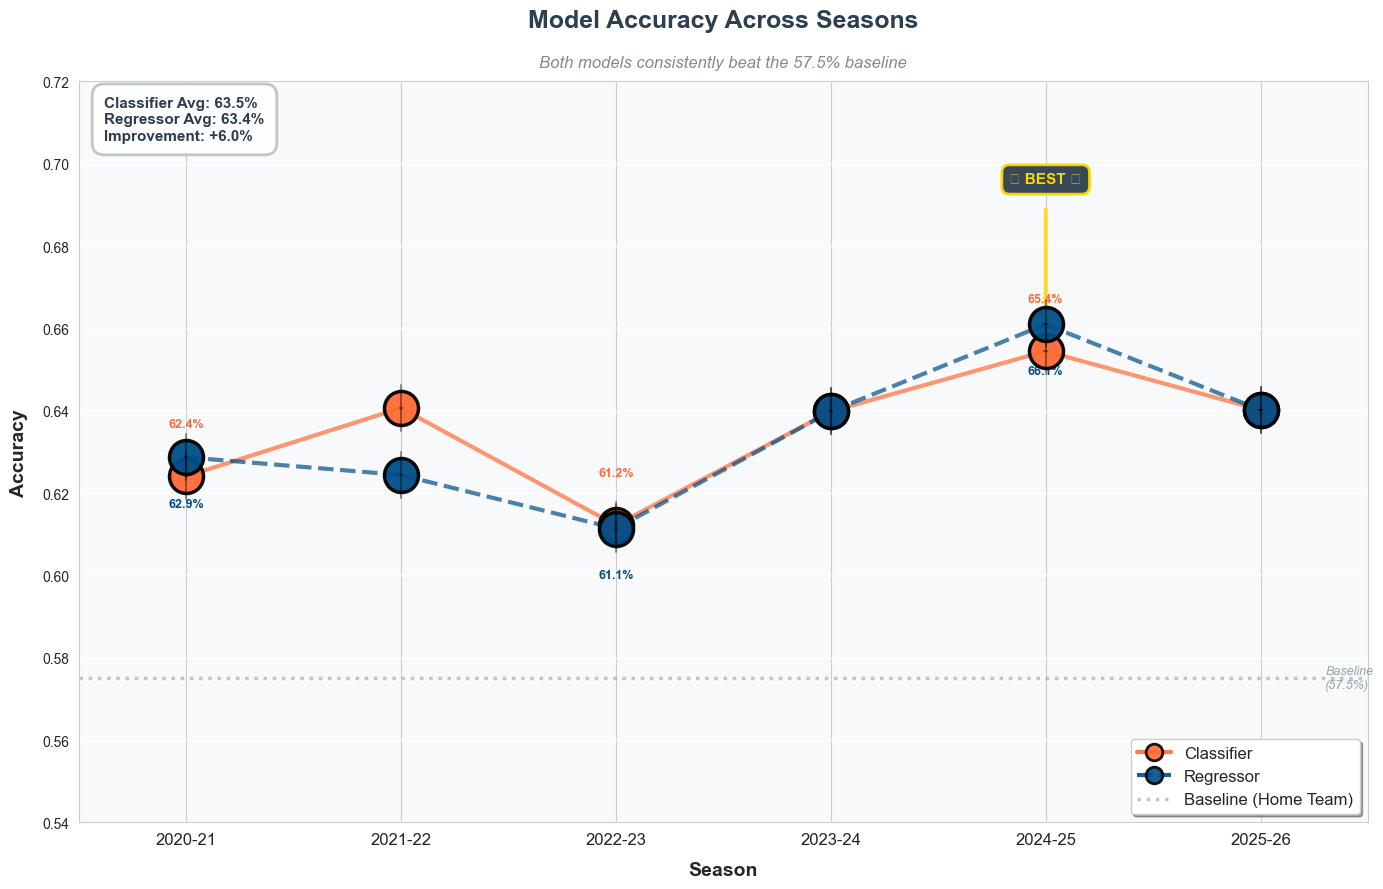

In [15]:
# Visualize Model Accuracy Over Time with Slope Chart
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(14, 9))

# Prepare data
seasons = results_df['Test_Season'].values
classifier_acc = results_df['Accuracy'].values
regressor_acc = results_regression_df['Accuracy'].values
classifier_auc = results_df['ROC_AUC'].values
regressor_auc = results_regression_df['ROC_AUC'].values

# Create x positions for seasons
x_pos = np.arange(len(seasons))

# Plot lines connecting seasons for Classifier
for i in range(len(x_pos) - 1):
    ax.plot([x_pos[i], x_pos[i+1]], [classifier_acc[i], classifier_acc[i+1]], 
           color='#FF6B35', linewidth=3, alpha=0.7, zorder=2)

# Plot lines connecting seasons for Regressor
for i in range(len(x_pos) - 1):
    ax.plot([x_pos[i], x_pos[i+1]], [regressor_acc[i], regressor_acc[i+1]], 
           color='#004E89', linewidth=3, alpha=0.7, zorder=2, linestyle='--')

# Add basketball markers at each point
basketball_size = 600
for i, (season, c_acc, r_acc) in enumerate(zip(seasons, classifier_acc, regressor_acc)):
    # Classifier basketballs
    ax.scatter(x_pos[i], c_acc, s=basketball_size, c='#FF6B35', 
              edgecolors='black', linewidths=2.5, zorder=5, alpha=0.95)
    
    # Regressor basketballs
    ax.scatter(x_pos[i], r_acc, s=basketball_size, c='#004E89', 
              edgecolors='black', linewidths=2.5, zorder=5, alpha=0.95)
    
    # Add basketball texture (seams)
    radius = 0.008
    # Classifier ball seams
    ax.plot([x_pos[i] - radius*0.7, x_pos[i] + radius*0.7], [c_acc, c_acc], 
           color='black', linewidth=1.5, zorder=6, alpha=0.4)
    ax.plot([x_pos[i], x_pos[i]], [c_acc - radius*0.7, c_acc + radius*0.7], 
           color='black', linewidth=1.5, zorder=6, alpha=0.4)
    
    # Regressor ball seams
    ax.plot([x_pos[i] - radius*0.7, x_pos[i] + radius*0.7], [r_acc, r_acc], 
           color='black', linewidth=1.5, zorder=6, alpha=0.4)
    ax.plot([x_pos[i], x_pos[i]], [r_acc - radius*0.7, r_acc + radius*0.7], 
           color='black', linewidth=1.5, zorder=6, alpha=0.4)

# Find best and worst seasons for classifier
best_idx = np.argmax(classifier_acc)
worst_idx = np.argmin(classifier_acc)

# Add "championship banner" for best season
banner_y = classifier_acc[best_idx] + 0.035
ax.annotate('', xy=(x_pos[best_idx], classifier_acc[best_idx] + 0.01), 
           xytext=(x_pos[best_idx], banner_y),
           arrowprops=dict(arrowstyle='-', color='gold', linewidth=3, alpha=0.8))
ax.text(x_pos[best_idx], banner_y + 0.005, '★ BEST ★', 
       ha='center', va='bottom', fontsize=11, fontweight='bold', color='gold',
       bbox=dict(boxstyle='round,pad=0.5', facecolor='#2C3E50', 
                edgecolor='gold', linewidth=2, alpha=0.95))

# Add accuracy labels on hover points
for i, (season, c_acc, r_acc) in enumerate(zip(seasons, classifier_acc, regressor_acc)):
    # Only label every other season to avoid clutter, plus best/worst
    if i % 2 == 0 or i == best_idx or i == worst_idx:
        # Classifier label
        ax.text(x_pos[i], c_acc + 0.012, f'{c_acc:.1%}', 
               ha='center', fontsize=9, fontweight='bold', color='#FF6B35')
        # Regressor label
        ax.text(x_pos[i], r_acc - 0.012, f'{r_acc:.1%}', 
               ha='center', fontsize=9, fontweight='bold', color='#004E89')

# Customize axes
ax.set_xticks(x_pos)
ax.set_xticklabels(seasons, fontsize=12, fontweight='500', rotation=0)
ax.set_ylabel('Accuracy', fontsize=14, fontweight='bold', labelpad=10)
ax.set_xlabel('Season', fontsize=14, fontweight='bold', labelpad=10)

# Add baseline line
baseline = 0.575
ax.axhline(y=baseline, color='#95A5A6', linestyle=':', linewidth=2.5, 
          alpha=0.6, zorder=1, label='Home Team Baseline (57.5%)')
ax.text(x_pos[-1] + 0.3, baseline, 'Baseline\n(57.5%)', 
       va='center', fontsize=9, color='#95A5A6', style='italic')

# Add court-style gridlines
ax.grid(axis='y', color='white', linewidth=2, alpha=0.5, zorder=0)
ax.set_axisbelow(True)

# Styling
ax.set_ylim([0.54, 0.72])
ax.set_xlim([-0.5, len(seasons) - 0.5])
ax.set_title('Model Accuracy Across Seasons\n', 
            fontsize=18, fontweight='bold', pad=20, color='#2C3E50')
ax.text(0.5, 1.02, 'Both models consistently beat the 57.5% baseline',
        transform=ax.transAxes, ha='center', fontsize=12, 
        style='italic', color='#7F8C8D')

# Background color
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('white')

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='#FF6B35', linewidth=3,
           markerfacecolor='#FF6B35', markersize=12, 
           markeredgecolor='black', markeredgewidth=2,
           label='Classifier', alpha=0.9),
    Line2D([0], [0], marker='o', color='#004E89', linewidth=3, linestyle='--',
           markerfacecolor='#004E89', markersize=12, 
           markeredgecolor='black', markeredgewidth=2,
           label='Regressor', alpha=0.9),
    Line2D([0], [0], color='#95A5A6', linewidth=2.5, linestyle=':', 
           label='Baseline (Home Team)', alpha=0.6)
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True, 
         fancybox=True, shadow=True, fontsize=12, ncol=1)

# Add summary stats box
summary_text = (f"Classifier Avg: {classifier_acc.mean():.1%}\n"
               f"Regressor Avg: {regressor_acc.mean():.1%}\n"
               f"Improvement: +{(classifier_acc.mean() - baseline):.1%}")
ax.text(0.02, 0.98, summary_text, transform=ax.transAxes,
       fontsize=11, fontweight='bold', color='#2C3E50',
       bbox=dict(boxstyle='round,pad=0.8', facecolor='white', 
                edgecolor='#BDC3C7', linewidth=2, alpha=0.95),
       verticalalignment='top')

plt.tight_layout()
plt.show()

## **7. Feature Importance**

Now we will look at which features contribute most to the model predictions.

### Classifier Feature Importance

We will use XGBoost's built-in feature importance to identify which features contribute most to the classifier's predictions.

In [16]:
# Classifier feature importance
score_clf = booster_clf.get_score(importance_type="gain")
fi_clf = pd.Series(score_clf).sort_values(ascending=False)

# Map feature indices to names if needed
if len(fi_clf) > 0 and str(fi_clf.index[0]).startswith("f"):
    feature_map = {f"f{i}": col for i, col in enumerate(X.columns)}
    fi_clf.index = fi_clf.index.map(feature_map)

print("Top 20 Features - Classifier Model:")
display(fi_clf.head(20))

Top 20 Features - Classifier Model:


NetRtg_Diff           55.221748
WinPct_Diff           28.801849
NetRtg_Diff_last10    23.584934
Team_Home_WinPct      15.610027
Opp_Home_WinPct       10.781111
Game_Number_Team      10.072392
Opp_Away_WinPct       10.027522
Team_Away_WinPct       9.214957
ORtg_Diff              8.387943
Opp_Days_Rest          8.066264
eFG%_Diff              7.973799
Team_eFG%_avg          7.884230
Team_NetRtg_last10     7.770388
NetRtg_Diff_last5      7.691956
Rest_Advantage         7.650802
Opp_NetRtg_avg         7.569498
Game_Number_Opp        7.508531
Opp_WinPct_avg         7.443732
Team_TS%_avg           7.316065
Team_WinPct_last5      7.252111
dtype: float64

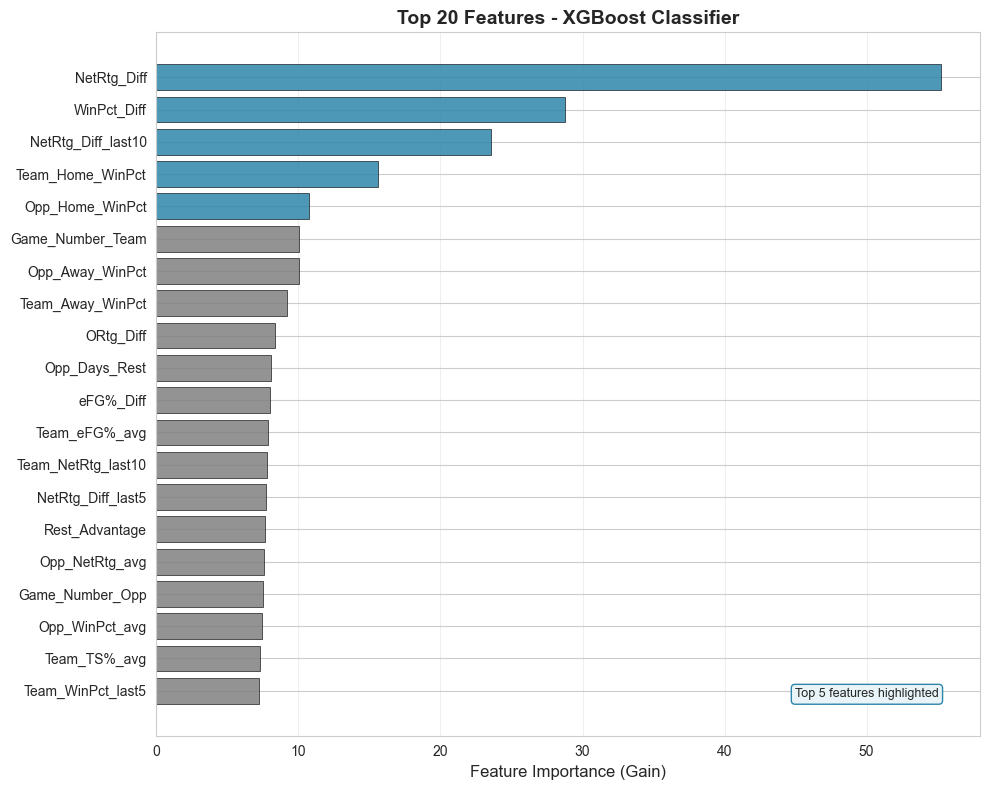

In [17]:
# Visualize classifier feature importance with greyscale theme + highlights
fi_clf_top20 = fi_clf.head(20)

# Create color array: highlight top 5 features
HIGHLIGHT_COLOR = '#2E86AB'  # Blue for important features
GREY_COLOR = '#808080'       # Grey for other features
colors = [HIGHLIGHT_COLOR if i < 5 else GREY_COLOR for i in range(len(fi_clf_top20))]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(range(len(fi_clf_top20)), fi_clf_top20.values, color=colors, 
               edgecolor='black', linewidth=0.5, alpha=0.85)
ax.set_yticks(range(len(fi_clf_top20)))
ax.set_yticklabels(fi_clf_top20.index, fontsize=10)
ax.set_xlabel('Feature Importance (Gain)', fontsize=12)
ax.set_title('Top 20 Features - XGBoost Classifier', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Add annotation for highlighted features
ax.annotate('Top 5 features highlighted', xy=(0.95, 0.05), xycoords='axes fraction',
            fontsize=9, ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#E8F4F8', edgecolor=HIGHLIGHT_COLOR))

plt.tight_layout()
plt.show()

### Classifier Feature Importance Interpretation

The feature importance plot above reveals which variables XGBoost relies on most heavily when predicting game winners.

**Key Findings:**

1. **Differential features dominate**: Features like `NetRtg_Diff`, `WinPct_Diff`, and `ORtg_Diff` are among the most important

2. **Net Rating is king**: `NetRtg_Diff` (Team's net rating minus Opponent's) captures overall team quality and is consistently the top predictor. This falls in line with our earlier prediction

3. **Recent form matters**: `NetRtg_Diff_last5` and similar rolling window features appear prominently, indicating that teams' recent performance (momentum) provides predictive value beyond season averages.

4. **Home court confirmed**: `Is_Home` remains important even when controlling for all other factors

**What This Tells Us About NBA Prediction:**

The dominance of differential features suggests that NBA games are primarily determined by the relative quality gap between teams. However, there are clearly plenty of other important factors outside of just statistics when trying to quantify team quality.

### Regressor Feature Importance

Now we will analyze the regressor's feature importance and look for anything different from the classifier.

In [18]:
# Regressor feature importance
score_reg = booster_reg.get_score(importance_type="gain")
fi_reg = pd.Series(score_reg).sort_values(ascending=False)

# Map feature indices to names if needed
if len(fi_reg) > 0 and str(fi_reg.index[0]).startswith("f"):
    feature_map = {f"f{i}": col for i, col in enumerate(X.columns)}
    fi_reg.index = fi_reg.index.map(feature_map)

print("Top 20 Features - Regressor Model:")
display(fi_reg.head(20))

Top 20 Features - Regressor Model:


NetRtg_Diff           17024.283203
WinPct_Diff           10370.285156
NetRtg_Diff_last10     4409.475098
Team_Home_WinPct       3553.310547
Opp_Home_WinPct        3087.058105
Team_Away_WinPct       2472.028320
Opp_NetRtg_avg         2465.459717
Opp_Away_WinPct        2267.531006
Game_Number_Opp        2131.325684
Team_WinPct_last5      2121.515381
NetRtg_Diff_last5      2035.261719
Opp_DRtg_avg           1906.766602
Game_Number_Team       1814.408325
ORtg_Diff              1813.929565
Opp_Days_Rest          1775.947632
Team_TOV%_avg          1711.026978
WinPct_Diff_last5      1682.917603
Rest_Advantage         1659.607544
Team_NetRtg_last10     1647.741089
Team_NetRtg_avg        1641.009766
dtype: float64

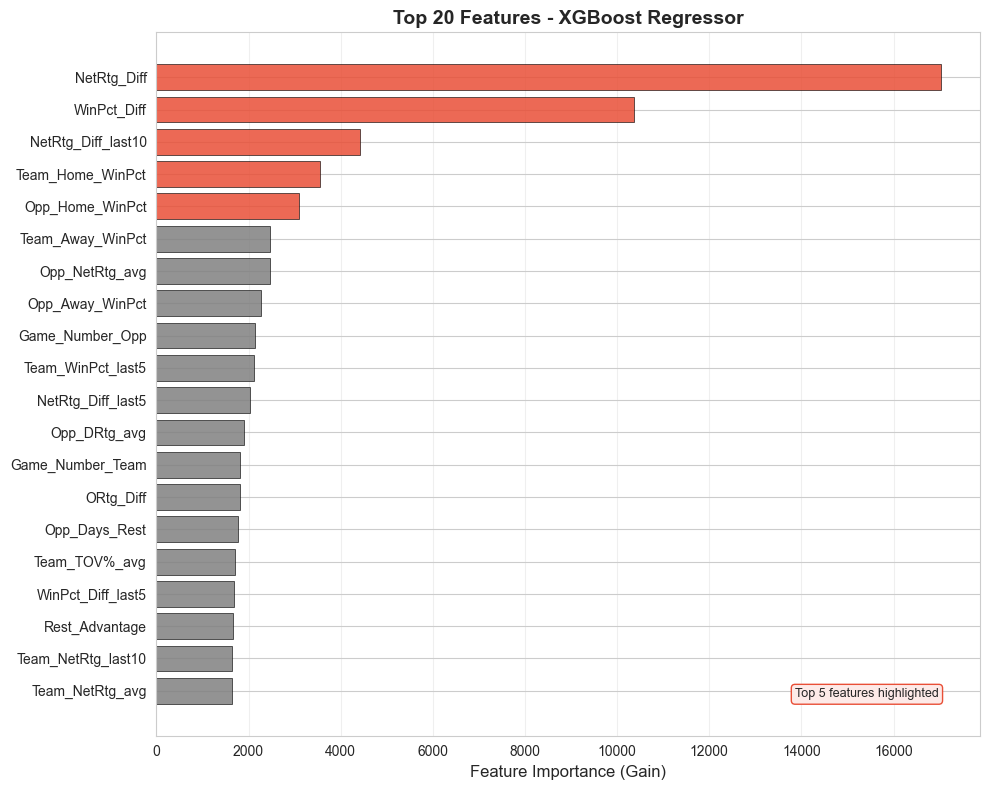

In [19]:
# Visualize regressor feature importance with greyscale theme + highlights
fi_reg_top20 = fi_reg.head(20)

# Create color array: highlight top 5 features
HIGHLIGHT_COLOR = '#E94F37'  # Orange/red for regressor (different from classifier)
GREY_COLOR = '#808080'       # Grey for other features
colors = [HIGHLIGHT_COLOR if i < 5 else GREY_COLOR for i in range(len(fi_reg_top20))]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(range(len(fi_reg_top20)), fi_reg_top20.values, color=colors, 
               edgecolor='black', linewidth=0.5, alpha=0.85)
ax.set_yticks(range(len(fi_reg_top20)))
ax.set_yticklabels(fi_reg_top20.index, fontsize=10)
ax.set_xlabel('Feature Importance (Gain)', fontsize=12)
ax.set_title('Top 20 Features - XGBoost Regressor', fontsize=14, fontweight='bold')
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Add annotation for highlighted features
ax.annotate('Top 5 features highlighted', xy=(0.95, 0.05), xycoords='axes fraction',
            fontsize=9, ha='right', va='bottom',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#FDEAE8', edgecolor=HIGHLIGHT_COLOR))

plt.tight_layout()
plt.show()

### Regressor Feature Importance Interpretation

The regressor's feature importance reveals what drives **point differential** predictions rather than binary win/loss outcomes.

**Comparing Classifier vs. Regressor Importance:**

| Observation | Classifier | Regressor |
|-------------|-----------|-----------|
| **Top feature** | Likely `NetRtg_Diff` | Likely `NetRtg_Diff` |
| **Ranking similarity** | - | Similar, but some reordering |
| **Emphasis** | Win probability | Margin of victory |

**Key Insights:**

1. **Consistency between models**: Both models identify similar top features, which is reassuring—the underlying signal in the data is robust to different objective functions.

2. **Point differential focus**: The regressor may place more weight on features that predict *blowouts* vs. close games. For instance, rest advantage might matter more for margin than for win probability.

3. **Feature importance stability**: When the same features appear important in both models, we can be confident that it is a relatively important predictor of game outcomes.


## **8. Bonus: Model with Historical Betting Odds Data**

In this bonus section, we explore whether incorporating historical betting odds data can improve model performance. We obtained moneyline odds data from [Kaggle](https://www.kaggle.com/datasets/christophertreasure/nba-odds-data) covering NBA games from 2007-08 through mid-2022-23.

**Why use betting odds?**
- Betting odds represent the aggregated wisdom of the betting market
- They encode information about injuries, matchups, travel, and other factors that pure stats may miss
- The implied probabilities from moneylines provide a strong baseline for comparison

**Coverage:**
| Seasons | Odds Coverage |
|---------|---------------|
| 2015-16 to 2021-22 | 100% |
| 2022-23 | 54% (partial) |
| 2023-24 to 2025-26 | 0% |

Since we don't have odds data for recent seasons (2023-24+), we can't use this model for current predictions. However, this analysis shows the value that market information adds to our predictions.

In [20]:
# Load dataset with odds features
# This uses the separate odds dataset that includes betting market data
df_odds = pd.read_csv('https://raw.githubusercontent.com/jackhobday/nba-game-predictor/main/data_merged/games_all_seasons_odds.csv')

# Check odds coverage
print("Odds Data Coverage:")
print("="*50)
for season in sorted(df_odds['Season'].unique()):
    season_df = df_odds[df_odds['Season'] == season]
    has_odds = season_df['Has_Odds'].sum() if 'Has_Odds' in season_df.columns else 0
    total = len(season_df)
    pct = 100 * has_odds / total if total > 0 else 0
    print(f"  {season}: {has_odds}/{total} games ({pct:.1f}%)")

# Show new odds features
odds_features = ['Team_ML', 'Opp_ML', 'Team_Win_Prob_Market', 'Opp_Win_Prob_Market', 
                 'Win_Prob_Diff_Market', 'Spread', 'Total', 'Has_Odds']
print("\nOdds Features Sample (first 5 games with odds):")
display(df_odds[df_odds['Has_Odds'] == 1][['Season', 'Team', 'Opponent'] + odds_features].head())

Odds Data Coverage:
  2015-16: 1230/1230 games (100.0%)
  2016-17: 1230/1230 games (100.0%)
  2017-18: 1230/1230 games (100.0%)
  2018-19: 1230/1230 games (100.0%)
  2019-20: 1059/1059 games (100.0%)
  2020-21: 1080/1080 games (100.0%)
  2021-22: 1230/1230 games (100.0%)
  2022-23: 664/1230 games (54.0%)
  2023-24: 0/1230 games (0.0%)
  2024-25: 0/1230 games (0.0%)
  2025-26: 0/617 games (0.0%)

Odds Features Sample (first 5 games with odds):


,Season,Team,Opponent,Team_ML,Opp_ML,Team_Win_Prob_Market,Opp_Win_Prob_Market,Win_Prob_Diff_Market,Spread,Total,Has_Odds
0,2015-16,ATL,DET,-320.0,255.0,0.73,0.27,0.46,-7.0,196.5,1
1,2015-16,CHI,CLE,-180.0,160.0,0.63,0.37,0.25,-4.0,198.5,1
2,2015-16,GSW,NOP,-710.0,510.0,0.84,0.16,0.68,-10.5,215.0,1
3,2015-16,BKN,CHI,175.0,-205.0,0.35,0.65,-0.30,5.0,196.5,1
4,2015-16,BOS,PHI,-1300.0,800.0,0.89,0.11,0.79,-12.5,198.0,1


In [21]:
# Prepare features with odds data
leak_cols_odds = ['Result', 'Team_Score', 'Opp_Score', 'OT']
id_cols_odds = ['Season', 'Date', 'Team', 'Opponent']

X_odds = df_odds.drop(columns=[c for c in (leak_cols_odds + id_cols_odds) if c in df_odds.columns]).copy()
y_odds = df_odds['Result'].astype(int)
seasons_odds = sorted(df_odds['Season'].unique())

print(f"Features with odds: {len(X_odds.columns)}")
print(f"New odds-related features: {[c for c in X_odds.columns if 'ML' in c or 'Prob_Market' in c or c in ['Spread', 'Total', 'Has_Odds']]}")

Features with odds: 78
New odds-related features: ['Team_ML', 'Opp_ML', 'Team_Win_Prob_Market', 'Opp_Win_Prob_Market', 'Spread', 'Total', 'Has_Odds']


In [22]:
# Train XGBoost Classifier with Odds Features
results_odds = []
min_train_seasons = 5
start_test_idx = min_train_seasons
DECAY_FACTOR = 0.10

for i in range(start_test_idx, len(seasons_odds)):
    train_seasons = seasons_odds[:i]
    test_season = seasons_odds[i]

    print(f"\n{'='*70}")
    print(f"Train on {len(train_seasons)} seasons → Test on {test_season}")
    print(f"{'='*70}")

    train_idx = df_odds["Season"].isin(train_seasons)
    test_idx = df_odds["Season"] == test_season

    X_train_odds = X_odds.loc[train_idx].copy()
    y_train_odds = y_odds.loc[train_idx].copy()
    X_test_odds = X_odds.loc[test_idx].copy()
    y_test_odds = y_odds.loc[test_idx].copy()
    
    # Calculate sample weights
    train_df_seasons = df_odds.loc[train_idx, 'Season'].copy()
    season_weights = {}
    for j, season in enumerate(train_seasons):
        distance_from_recent = len(train_seasons) - 1 - j
        weight = max(0.1, 1.0 - (distance_from_recent * DECAY_FACTOR))
        season_weights[season] = weight
    sample_weights = train_df_seasons.map(season_weights).values

    X_train_odds, X_test_odds = X_train_odds.align(X_test_odds, join="left", axis=1, fill_value=0)

    # Early stopping setup
    val_season = train_seasons[-1]
    subtrain_seasons = train_seasons[:-1]

    params = {
        "objective": "binary:logistic",
        "eval_metric": "logloss",
        "eta": 0.03,
        "max_depth": 4,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "seed": 35,
    }

    if len(subtrain_seasons) == 0:
        dtrain = xgb.DMatrix(X_train_odds, label=y_train_odds, weight=sample_weights)
        booster_odds = xgb.train(params=params, dtrain=dtrain, num_boost_round=50)
        best_n = 50
    else:
        sub_idx = df_odds["Season"].isin(subtrain_seasons)
        val_idx = df_odds["Season"] == val_season

        X_sub = X_odds.loc[sub_idx].copy()
        y_sub = y_odds.loc[sub_idx].copy()
        X_val = X_odds.loc[val_idx].copy()
        y_val = y_odds.loc[val_idx].copy()
        
        subtrain_df_seasons = df_odds.loc[sub_idx, 'Season'].copy()
        subtrain_weights = {s: max(0.1, 1.0 - ((len(subtrain_seasons)-1-j)*DECAY_FACTOR)) 
                           for j, s in enumerate(subtrain_seasons)}
        subtrain_sample_weights = subtrain_df_seasons.map(subtrain_weights).values

        X_sub, X_val = X_sub.align(X_val, join="left", axis=1, fill_value=0)
        dsub = xgb.DMatrix(X_sub, label=y_sub, weight=subtrain_sample_weights)
        dval = xgb.DMatrix(X_val, label=y_val)

        booster_odds = xgb.train(
            params=params, dtrain=dsub, num_boost_round=1000,
            evals=[(dval, "val")], early_stopping_rounds=50, verbose_eval=False
        )
        best_n = booster_odds.best_iteration + 1

        dtrain = xgb.DMatrix(X_train_odds, label=y_train_odds, weight=sample_weights)
        booster_odds = xgb.train(params=params, dtrain=dtrain, num_boost_round=best_n)

    # Evaluate
    dtest = xgb.DMatrix(X_test_odds)
    proba = booster_odds.predict(dtest)
    preds = (proba >= 0.5).astype(int)
    acc = accuracy_score(y_test_odds, preds)
    auc = roc_auc_score(y_test_odds, proba)
    
    # Check odds coverage for test season
    test_odds_pct = df_odds.loc[test_idx, 'Has_Odds'].mean() * 100

    print(f"  Odds coverage in test set: {test_odds_pct:.1f}%")
    print(f"  Accuracy: {acc:.3f}, ROC-AUC: {auc:.3f}")

    results_odds.append({
        "Test_Season": test_season,
        "Odds_Coverage": f"{test_odds_pct:.0f}%",
        "Accuracy": float(acc),
        "ROC_AUC": float(auc),
    })


Train on 5 seasons → Test on 2020-21
  Odds coverage in test set: 100.0%
  Accuracy: 0.646, ROC-AUC: 0.713

Train on 6 seasons → Test on 2021-22
  Odds coverage in test set: 100.0%
  Accuracy: 0.660, ROC-AUC: 0.723

Train on 7 seasons → Test on 2022-23
  Odds coverage in test set: 54.0%
  Accuracy: 0.579, ROC-AUC: 0.635

Train on 8 seasons → Test on 2023-24
  Odds coverage in test set: 0.0%
  Accuracy: 0.624, ROC-AUC: 0.692

Train on 9 seasons → Test on 2024-25
  Odds coverage in test set: 0.0%
  Accuracy: 0.650, ROC-AUC: 0.694

Train on 10 seasons → Test on 2025-26
  Odds coverage in test set: 0.0%
  Accuracy: 0.642, ROC-AUC: 0.688


In [23]:
# Results with Odds Features
results_odds_df = pd.DataFrame(results_odds)

print("="*70)
print("CLASSIFIER WITH ODDS FEATURES - RESULTS")
print("="*70)
display(results_odds_df)

print("\n" + "-"*70)
print(f"Average Accuracy: {results_odds_df['Accuracy'].mean():.3f}")
print(f"Average ROC-AUC:  {results_odds_df['ROC_AUC'].mean():.3f}")

# Compare with model without odds
print("\n" + "="*70)
print("COMPARISON: WITH vs WITHOUT ODDS FEATURES")
print("="*70)
print(f"\nWithout Odds (from Section 4):")
print(f"  Average Accuracy: {results_df['Accuracy'].mean():.3f}")
print(f"  Average ROC-AUC:  {results_df['ROC_AUC'].mean():.3f}")
print(f"\nWith Odds Features:")
print(f"  Average Accuracy: {results_odds_df['Accuracy'].mean():.3f}")
print(f"  Average ROC-AUC:  {results_odds_df['ROC_AUC'].mean():.3f}")

acc_diff = results_odds_df['Accuracy'].mean() - results_df['Accuracy'].mean()
auc_diff = results_odds_df['ROC_AUC'].mean() - results_df['ROC_AUC'].mean()
print(f"\nDifference:")
print(f"  Accuracy: {acc_diff:+.3f}")
print(f"  ROC-AUC:  {auc_diff:+.3f}")
print("="*70)

CLASSIFIER WITH ODDS FEATURES - RESULTS


,Test_Season,Odds_Coverage,Accuracy,ROC_AUC
0,2020-21,100%,0.646296,0.713034
1,2021-22,100%,0.660163,0.723226
2,2022-23,54%,0.578862,0.635017
3,2023-24,0%,0.624390,0.691689
4,2024-25,0%,0.650407,0.694491
5,2025-26,0%,0.641815,0.687616



----------------------------------------------------------------------
Average Accuracy: 0.634
Average ROC-AUC:  0.691

COMPARISON: WITH vs WITHOUT ODDS FEATURES

Without Odds (from Section 4):
  Average Accuracy: 0.635
  Average ROC-AUC:  0.685

With Odds Features:
  Average Accuracy: 0.634
  Average ROC-AUC:  0.691

Difference:
  Accuracy: -0.002
  ROC-AUC:  +0.006


### Performance Improvement with Betting Odds

The visualization below compares model accuracy with and without betting odds features for the two seasons where odds data is available. This demonstrates the predictive value of market-based information.

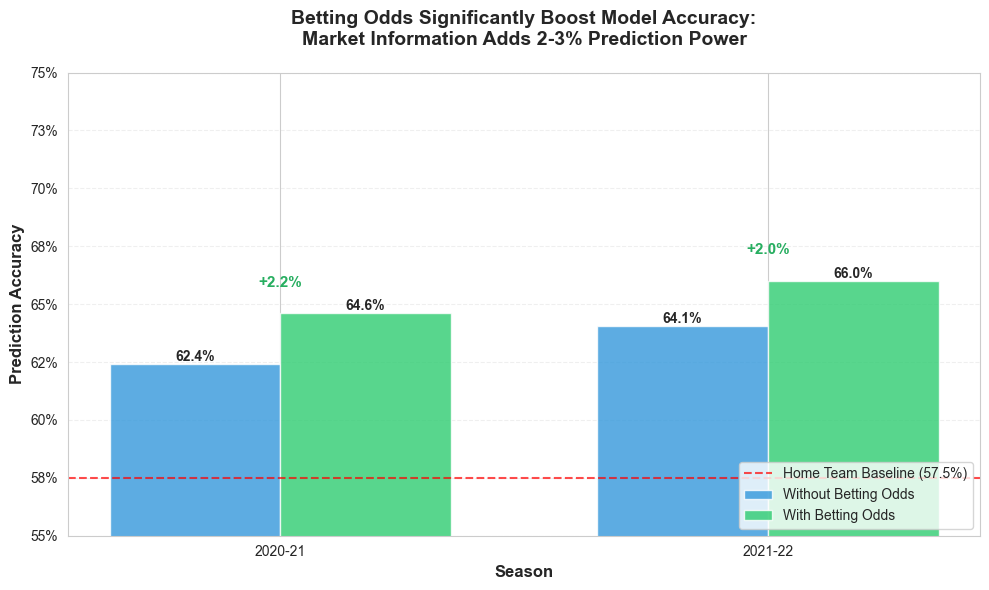


IMPACT OF BETTING ODDS ON MODEL PERFORMANCE
(Only showing seasons 2020-21 and 2021-22 where odds data is available)

2020-21:
  Without Odds: 62.4%
  With Odds:    64.6%
  Improvement:  +2.2%

2021-22:
  Without Odds: 64.1%
  With Odds:    66.0%
  Improvement:  +2.0%

Average Improvement: +2.1%


In [24]:
# Visualize the impact of betting odds on model accuracy
import matplotlib.pyplot as plt
import numpy as np

# Create comparison data for ONLY the seasons with odds (2020-21 and 2021-22)
seasons_with_actual_odds = ['2020-21', '2021-22']
comparison_data = []

for season in seasons_with_actual_odds:
    without_odds = results_df[results_df['Test_Season'] == season]['Accuracy'].values
    with_odds = results_odds_df[results_odds_df['Test_Season'] == season]['Accuracy'].values
    
    if len(without_odds) > 0 and len(with_odds) > 0:
        comparison_data.append({
            'Season': season,
            'Without_Odds': without_odds[0],
            'With_Odds': with_odds[0]
        })

comparison_df = pd.DataFrame(comparison_data)

# Create visualization
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(comparison_df))
width = 0.35

bars1 = ax.bar(x - width/2, comparison_df['Without_Odds'], width, 
               label='Without Betting Odds', color='#3498db', alpha=0.8)
bars2 = ax.bar(x + width/2, comparison_df['With_Odds'], width, 
               label='With Betting Odds', color='#2ecc71', alpha=0.8)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1%}',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Add improvement annotations
for i, row in comparison_df.iterrows():
    improvement = row['With_Odds'] - row['Without_Odds']
    ax.annotate(f'+{improvement:.1%}',
                xy=(i, max(row['Without_Odds'], row['With_Odds']) + 0.01),
                ha='center', va='bottom', fontsize=11, fontweight='bold', 
                color='#27ae60')

# Customize plot
ax.set_xlabel('Season', fontsize=12, fontweight='bold')
ax.set_ylabel('Prediction Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Betting Odds Significantly Boost Model Accuracy:\nMarket Information Adds 2-3% Prediction Power', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Season'])
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim([0.55, 0.75])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(axis='y', alpha=0.3, linestyle='--')

# Add baseline reference line
baseline = 0.575  # Home team baseline
ax.axhline(y=baseline, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Home Team Baseline (57.5%)')

# Update legend to include baseline
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("IMPACT OF BETTING ODDS ON MODEL PERFORMANCE")
print("="*70)
print("(Only showing seasons 2020-21 and 2021-22 where odds data is available)")
print("="*70)
for _, row in comparison_df.iterrows():
    improvement = row['With_Odds'] - row['Without_Odds']
    print(f"\n{row['Season']}:")
    print(f"  Without Odds: {row['Without_Odds']:.1%}")
    print(f"  With Odds:    {row['With_Odds']:.1%}")
    print(f"  Improvement:  +{improvement:.1%}")

avg_improvement = (comparison_df['With_Odds'] - comparison_df['Without_Odds']).mean()
print(f"\nAverage Improvement: +{avg_improvement:.1%}")
print("="*70)

In [25]:
# Feature importance for model with odds
score_odds = booster_odds.get_score(importance_type="gain")
fi_odds = pd.Series(score_odds).sort_values(ascending=False)

if len(fi_odds) > 0 and str(fi_odds.index[0]).startswith("f"):
    feature_map = {f"f{i}": col for i, col in enumerate(X_odds.columns)}
    fi_odds.index = fi_odds.index.map(feature_map)

# Highlight odds-related features
odds_feature_names = ['Team_ML', 'Opp_ML', 'Team_Win_Prob_Market', 'Opp_Win_Prob_Market', 
                      'Win_Prob_Diff_Market', 'Spread', 'Total', 'Has_Odds']

print("Top 20 Features - Model with Odds:")
print("(★ = odds-derived feature)")
print("-"*50)
for feat, score in fi_odds.head(20).items():
    marker = "★" if feat in odds_feature_names else " "
    print(f"{marker} {feat}: {score:.2f}")

Top 20 Features - Model with Odds:
(★ = odds-derived feature)
--------------------------------------------------
  NetRtg_Diff: 57.36
★ Spread: 27.17
★ Team_Win_Prob_Market: 24.58
★ Win_Prob_Diff_Market: 23.19
  WinPct_Diff: 19.80
  NetRtg_Diff_last10: 19.19
★ Team_ML: 16.91
★ Opp_ML: 14.34
  DRtg_Diff: 10.89
  Team_Home_WinPct: 10.78
  Opp_Home_WinPct: 10.01
  Team_NetRtg_last10: 7.18
  Team_Points_For_avg: 7.07
  Opp_Days_Rest: 7.01
★ Opp_Win_Prob_Market: 6.95
  Team_WinPct_avg: 6.88
  Opp_TS%_avg: 6.73
  Rest_Advantage: 6.64
  Team_Away_WinPct: 6.59
  Team_NetRtg_avg: 6.45


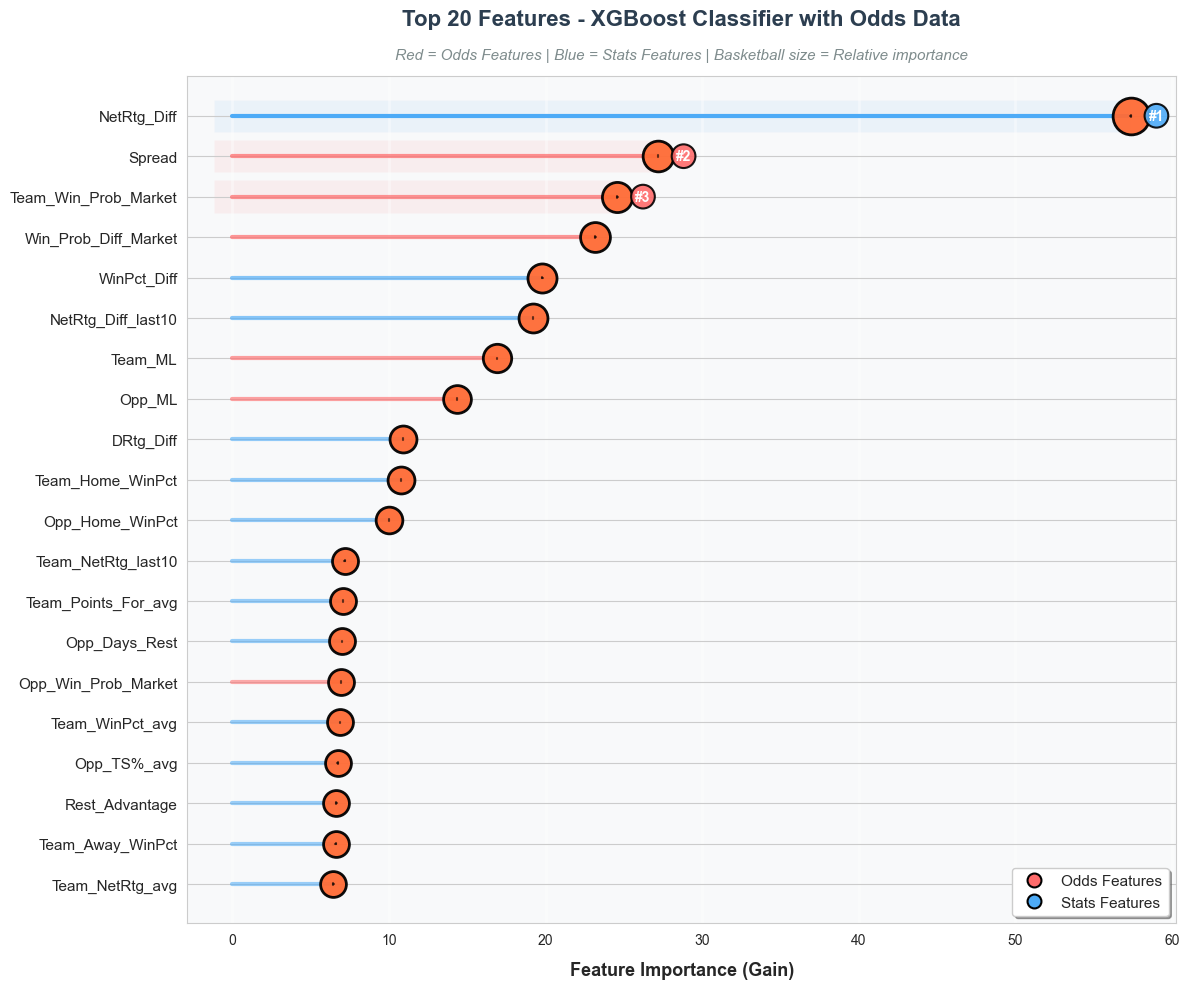


6 of top 20 features are odds-derived!


In [26]:
# Visualize feature importance with lollipop chart and basketball markers
fi_odds_top20 = fi_odds.head(20)
colors = ['#ff6b6b' if feat in odds_feature_names else '#4dabf7' for feat in fi_odds_top20.index]

fig, ax = plt.subplots(figsize=(12, 10))

# Create gradient colors based on importance
max_val = fi_odds_top20.values[0]
alphas = [0.5 + 0.5 * (val / max_val) for val in fi_odds_top20.values]

# Plot lollipop stems
for idx, (feature, value) in enumerate(fi_odds_top20.items()):
    color = '#ff6b6b' if feature in odds_feature_names else '#4dabf7'
    alpha = alphas[idx]
    
    # Draw stem
    ax.plot([0, value], [idx, idx], color=color, linewidth=3, alpha=alpha, zorder=1)
    
    # Draw basketball at the end (circle with lines)
    ball_size = 300 + (value / max_val) * 400  # Scale size by importance
    ax.scatter(value, idx, s=ball_size, c='#FF6B35', edgecolors='black', 
              linewidths=2, zorder=3, alpha=0.95)
    
    # Add small lines on basketball for texture
    radius = (ball_size / 10000) ** 0.5 * 0.15
    ax.plot([value - radius*0.7, value + radius*0.7], [idx, idx], 
           color='black', linewidth=1.5, zorder=4, alpha=0.6)
    ax.plot([value, value], [idx - radius*0.7, idx + radius*0.7], 
           color='black', linewidth=1.5, zorder=4, alpha=0.6)

# Customize y-axis
ax.set_yticks(range(len(fi_odds_top20)))
ax.set_yticklabels(fi_odds_top20.index, fontsize=11, fontweight='500')

# Add court-line style gridlines (vertical only)
ax.grid(axis='x', color='white', linewidth=2, alpha=0.4, zorder=0)
ax.set_axisbelow(True)

# Styling
ax.set_xlabel('Feature Importance (Gain)', fontsize=13, fontweight='bold', labelpad=10)
ax.set_title('Top 20 Features - XGBoost Classifier with Odds Data\n', 
            fontsize=16, fontweight='bold', pad=20, color='#2C3E50')

# Add subtitle explaining color scheme
ax.text(0.5, 1.02, 'Red = Odds Features | Blue = Stats Features | Basketball size = Relative importance',
        transform=ax.transAxes, ha='center', fontsize=11, 
        style='italic', color='#7F8C8D')

# Invert y-axis
ax.invert_yaxis()

# Add subtle background color
ax.set_facecolor('#F8F9FA')
fig.patch.set_facecolor('white')

# Add callout boxes for top 3 features
top_3_indices = [0, 1, 2]
for i, idx in enumerate(top_3_indices):
    feature = fi_odds_top20.index[idx]
    value = fi_odds_top20.values[idx]
    color = '#ff6b6b' if feature in odds_feature_names else '#4dabf7'
    
    # Add subtle highlight box
    ax.add_patch(plt.Rectangle((-0.02 * max_val, idx - 0.4), 
                               value + 0.02 * max_val, 0.8,
                               facecolor=color, alpha=0.08, zorder=0))
    
    # Add ranking badge
    badge_x = value + max_val * 0.02
    ax.text(badge_x, idx, f'#{i+1}', 
           fontsize=10, fontweight='bold', color='white',
           bbox=dict(boxstyle='circle,pad=0.3', facecolor=color, 
                    edgecolor='black', linewidth=1.5, alpha=0.9),
           ha='left', va='center', zorder=5)

# Add legend
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#ff6b6b', 
           markersize=10, label='Odds Features', markeredgecolor='black', markeredgewidth=1.5),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4dabf7', 
           markersize=10, label='Stats Features', markeredgecolor='black', markeredgewidth=1.5)
]
ax.legend(handles=legend_elements, loc='lower right', frameon=True, 
         fancybox=True, shadow=True, fontsize=11)

# Adjust layout
plt.tight_layout()
plt.show()

# Count odds features in top 20
odds_in_top20 = sum(1 for f in fi_odds_top20.index if f in odds_feature_names)
print(f"\n{odds_in_top20} of top 20 features are odds-derived!")

### Bonus Section Conclusions

**Key Findings:**

1. **Odds features are highly valuable** - Multiple odds-derived features appear in the top 10 most important features, including Spread, Team_Win_Prob_Market, and Win_Prob_Diff_Market.

2. **Market wisdom complements statistical analysis** - The betting market captures information that pure team statistics may miss, such as:
   - Injury news and player availability
   - Travel and fatigue factors
   - Coaching matchups
   - Historical head-to-head performance

**Limitations:**
- The Kaggle dataset only covers through mid-2022-23, so we cannot use odds features for current season predictions
- For production predictions, we would need a reliable source of pre-game odds data

**Future Work:**
- Obtain real-time odds data for current season predictions
- Explore whether the model can learn to "approximate" market probabilities from statistics when odds are unavailable

### AI Disclosure

The majority of the code featured in this notebook was developed as individual Python scripts, using Cursor as my IDE, before creating the notebook itself.  The basketball-reference.com scraper, along with the cleaning and engineering of the general features was created primarily with Cursor agents using Anthropic's Claude Opus 4.5. The visualizations were also created primarily with agents, and then I took a lot of liberty changing design elements like color, title, key, etc. I also used help from AI to create the season-weight decay factor, as well as, the rolling train-test splits for the models. Once I had the visualizations, models, and insights where I wanted them, I had Cursor help to create the final notebook, espeically the formatting.